# Representation Learning 101

* intuitive visualization

* information preservation with minimum dimension features

* help structural discovery and mechanistic investigation

## Chapter 1. Intro about Representation Learning


with just a change of representation coordinates, we can achieve perfect classification with the same linear classifier, same data processing task

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib_inline.backend_inline import set_matplotlib_formats

# Use an opaque RGB output format: this avoids black rectangles in dark notebook themes.
set_matplotlib_formats("jpeg")

rng = np.random.default_rng(12)
n_per_state = 360
theta_inner = rng.uniform(0, 2 * np.pi, n_per_state)
theta_outer = rng.uniform(0, 2 * np.pi, n_per_state)
radius_inner = rng.normal(0.72, 0.075, n_per_state)
radius_outer = rng.normal(1.48, 0.095, n_per_state)

X = np.vstack([
    np.c_[radius_inner * np.cos(theta_inner), radius_inner * np.sin(theta_inner)],
    np.c_[radius_outer * np.cos(theta_outer), radius_outer * np.sin(theta_outer)],
])
y = np.r_[np.zeros(n_per_state, dtype=int), np.ones(n_per_state, dtype=int)]

split_rng = np.random.default_rng(8)
train_parts, test_parts = [], []
for state in (0, 1):
    state_idx = np.flatnonzero(y == state)
    split_rng.shuffle(state_idx)
    cut = int(0.70 * len(state_idx))
    train_parts.append(state_idx[:cut])
    test_parts.append(state_idx[cut:])
train_idx = np.concatenate(train_parts)
test_idx = np.concatenate(test_parts)

def fit_logistic(features, target, l2=1e-3, max_iter=60):
    """Small Newton-solver logistic regression, standardized using training data only."""
    features = np.asarray(features, dtype=float)
    if features.ndim == 1:
        features = features[:, None]
    mean = features.mean(axis=0)
    scale = features.std(axis=0)
    scale[scale == 0] = 1.0
    standardized = (features - mean) / scale
    design = np.c_[np.ones(len(features)), standardized]
    beta = np.zeros(design.shape[1])
    penalty = np.diag(np.r_[0.0, np.full(design.shape[1] - 1, l2)])
    for _ in range(max_iter):
        logits = np.clip(design @ beta, -30, 30)
        probability = 1 / (1 + np.exp(-logits))
        variance = np.clip(probability * (1 - probability), 1e-8, None)
        gradient = design.T @ (probability - target) + penalty @ beta
        hessian = design.T @ (design * variance[:, None]) + penalty
        step = np.linalg.solve(hessian, gradient)
        beta -= step
        if np.linalg.norm(step) < 1e-9:
            break
    return {"beta": beta, "mean": mean, "scale": scale}

def predict_probability(model, features):
    features = np.asarray(features, dtype=float)
    if features.ndim == 1:
        features = features[:, None]
    design = np.c_[np.ones(len(features)), (features - model["mean"]) / model["scale"]]
    logits = np.clip(design @ model["beta"], -30, 30)
    return 1 / (1 + np.exp(-logits))

def model_score(model, features, target):
    return np.mean((predict_probability(model, features) >= 0.5) == target)

second_order = lambda A: np.c_[A[:, 0] ** 2, A[:, 1] ** 2]

raw_model = fit_logistic(X[train_idx], y[train_idx])
quad_model = fit_logistic(second_order(X[train_idx]), y[train_idx])

raw_accuracy = model_score(raw_model, X[test_idx], y[test_idx])
quad_accuracy = model_score(quad_model, second_order(X[test_idx]), y[test_idx])

COLORS = {0: "#18A6A6", 1: "#F05A67"}
STATE_NAMES = {0: "Inner state", 1: "Outer state"}
decision_cmap = LinearSegmentedColormap.from_list(
    "state_probability", [COLORS[0], "#F8FAFC", COLORS[1]]
)
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

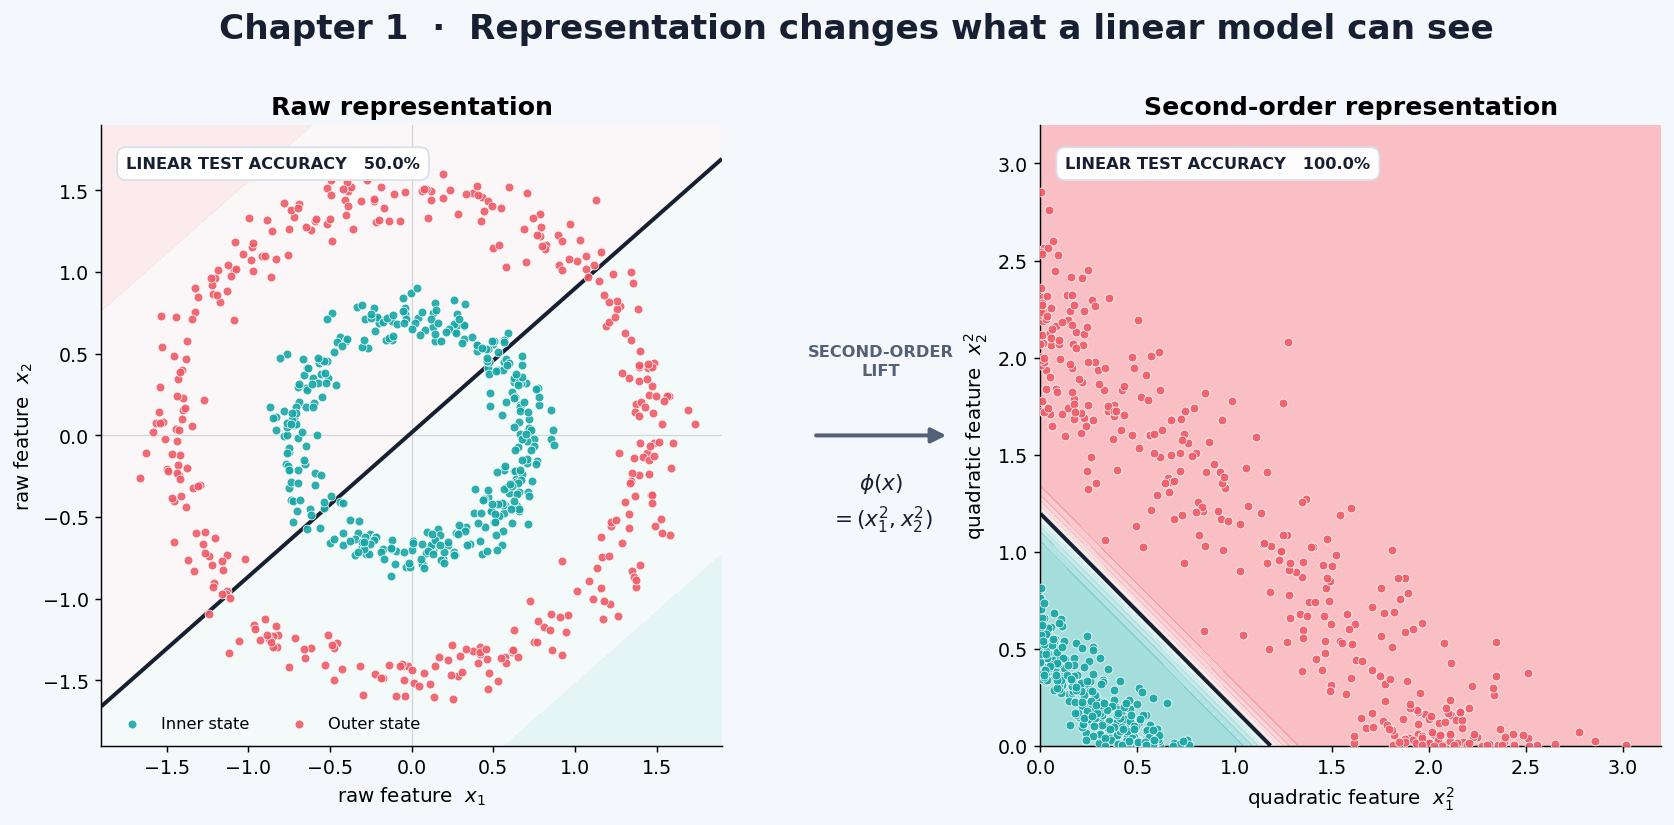

In [2]:
fig = plt.figure(figsize=(15.5, 6.2), facecolor="#F4F7FB")
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.24, 1], wspace=0.18)
ax_raw = fig.add_subplot(gs[0, 0])
ax_map = fig.add_subplot(gs[0, 1])
ax_quad = fig.add_subplot(gs[0, 2])

grid_lim = 1.9
g = np.linspace(-grid_lim, grid_lim, 320)
gx, gy = np.meshgrid(g, g)
raw_grid = np.c_[gx.ravel(), gy.ravel()]
p_raw = predict_probability(raw_model, raw_grid).reshape(gx.shape)

ax_raw.contourf(gx, gy, p_raw, levels=np.linspace(0, 1, 13), cmap=decision_cmap, alpha=0.42)
ax_raw.contour(gx, gy, p_raw, levels=[0.5], colors="#172033", linewidths=2.2)
for state in (0, 1):
    mask = y == state
    ax_raw.scatter(
        X[mask, 0], X[mask, 1], s=24, c=COLORS[state], label=STATE_NAMES[state],
        edgecolors="white", linewidths=0.45, alpha=0.90, zorder=3
    )
ax_raw.axhline(0, color="#172033", lw=0.7, alpha=0.16)
ax_raw.axvline(0, color="#172033", lw=0.7, alpha=0.16)
ax_raw.set(xlabel=r"raw feature  $x_1$", ylabel=r"raw feature  $x_2$",
           title="Raw representation")
ax_raw.set_aspect("equal")
ax_raw.set_xlim(-grid_lim, grid_lim)
ax_raw.set_ylim(-grid_lim, grid_lim)
ax_raw.text(
    0.04, 0.95, f"LINEAR TEST ACCURACY   {raw_accuracy:.1%}", transform=ax_raw.transAxes,
    ha="left", va="top", color="#172033", fontsize=9, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.55", fc="white", ec="#D8DFEA", lw=1.0, alpha=0.96)
)
ax_raw.legend(loc="lower left", frameon=False, ncol=2, fontsize=9)

ax_map.set_axis_off()
ax_map.annotate(
    "", xy=(0.96, 0.50), xytext=(0.04, 0.50), xycoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", color="#536078", lw=2.2, mutation_scale=17)
)
ax_map.text(0.50, 0.62, "SECOND-ORDER\nLIFT", ha="center", va="center",
            fontsize=9, color="#536078", fontweight="bold", linespacing=1.35)
ax_map.text(0.50, 0.39, r"$\phi(x)$" + "\n" + r"$=(x_1^2, x_2^2)$", ha="center", va="center",
            fontsize=12, color="#172033", linespacing=1.4)

Phi = second_order(X)
phi_max = Phi.max() * 1.06
u = np.linspace(0, phi_max, 320)
gu, gv = np.meshgrid(u, u)
phi_grid = np.c_[gu.ravel(), gv.ravel()]
p_quad = predict_probability(quad_model, phi_grid).reshape(gu.shape)

ax_quad.contourf(gu, gv, p_quad, levels=np.linspace(0, 1, 13), cmap=decision_cmap, alpha=0.42)
ax_quad.contour(gu, gv, p_quad, levels=[0.5], colors="#172033", linewidths=2.2)
for state in (0, 1):
    mask = y == state
    ax_quad.scatter(
        Phi[mask, 0], Phi[mask, 1], s=24, c=COLORS[state],
        edgecolors="white", linewidths=0.45, alpha=0.90, zorder=3
    )
ax_quad.set(xlabel=r"quadratic feature  $x_1^2$", ylabel=r"quadratic feature  $x_2^2$",
            title="Second-order representation")
ax_quad.set_aspect("equal")
ax_quad.set_xlim(0, phi_max)
ax_quad.set_ylim(0, phi_max)
ax_quad.text(
    0.04, 0.95, f"LINEAR TEST ACCURACY   {quad_accuracy:.1%}", transform=ax_quad.transAxes,
    ha="left", va="top", color="#172033", fontsize=9, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.55", fc="white", ec="#D8DFEA", lw=1.0, alpha=0.96)
)

fig.suptitle("Chapter 1  ·  Representation changes what a linear model can see",
             x=0.5, y=1.02, fontsize=19, fontweight="bold", color="#172033")
plt.show()

notice that adding two current coordinates $x_1^2+x_2^2$ means the squared distance of data samples from origin point, serving as the key property for two classes of data samples (the line structure within the right figure shows this). 

so we can further use that as the mechanism intuition, and go back to the original representation space again:

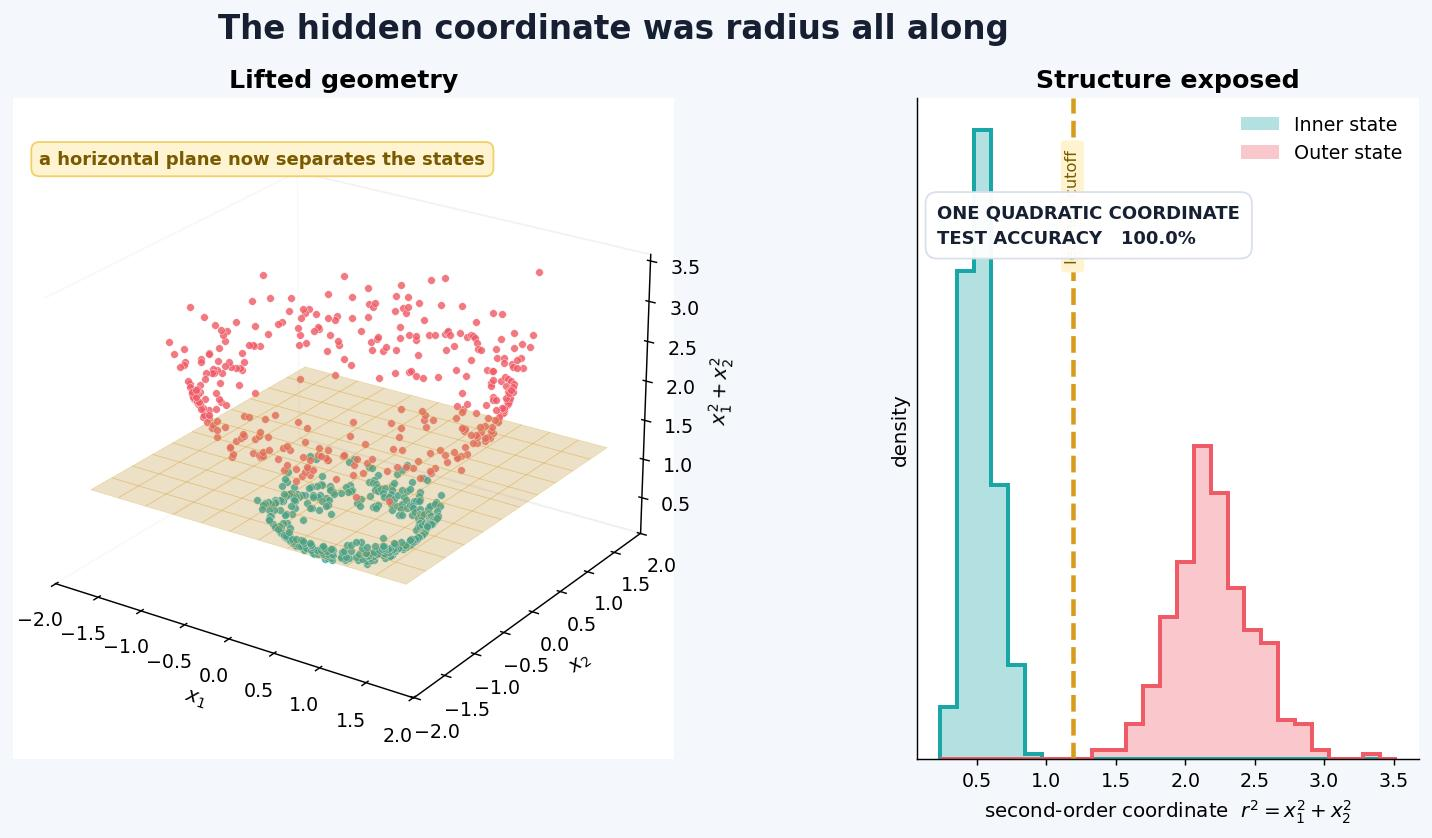

In [ ]:
# A geometric view: the quadratic lift reveals radius squared as the separating coordinate
r2 = np.sum(X ** 2, axis=1)
radial_model = fit_logistic(r2[train_idx, None], y[train_idx])
radial_cut = float(
    radial_model["mean"][0]
    - radial_model["scale"][0] * radial_model["beta"][0] / radial_model["beta"][1]
)

fig = plt.figure(figsize=(15.5, 6.6), facecolor="#F4F7FB")
gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 0.75], wspace=0.12)
ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax_hist = fig.add_subplot(gs[0, 1])

for state in (0, 1):
    mask = y == state
    ax3d.scatter(
        X[mask, 0], X[mask, 1], r2[mask], s=18, c=COLORS[state],
        edgecolors="white", linewidths=0.25, alpha=0.82, depthshade=False
    )
plane_axis = np.linspace(-1.75, 1.75, 12)
px, py = np.meshgrid(plane_axis, plane_axis)
ax3d.plot_surface(
    px, py, np.full_like(px, radial_cut), color="#FFC857", alpha=0.30,
    edgecolor="#D89B1D", linewidth=0.35, rstride=1, cstride=1
)
ax3d.set(xlabel=r"$x_1$", ylabel=r"$x_2$", zlabel=r"$x_1^2+x_2^2$",
         title="Lifted geometry")
ax3d.view_init(elev=24, azim=-56)
ax3d.set_box_aspect((1, 1, 0.72))
ax3d.xaxis.pane.set_facecolor((1, 1, 1, 0.65))
ax3d.yaxis.pane.set_facecolor((1, 1, 1, 0.65))
ax3d.zaxis.pane.set_facecolor((1, 1, 1, 0.65))
ax3d.grid(False)
ax3d.text2D(
    0.04, 0.90, "a horizontal plane now separates the states",
    transform=ax3d.transAxes, color="#7A5A00", fontsize=10, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.45", fc="#FFF4CF", ec="#F1CF63", alpha=0.96)
)

bins = np.linspace(r2.min() * 0.9, r2.max() * 1.05, 28)
for state in (0, 1):
    mask = y == state
    ax_hist.hist(
        r2[mask], bins=bins, density=True, histtype="stepfilled",
        color=COLORS[state], alpha=0.33, linewidth=0, label=STATE_NAMES[state]
    )
    ax_hist.hist(r2[mask], bins=bins, density=True, histtype="step",
                 color=COLORS[state], linewidth=2.2)
ax_hist.axvline(radial_cut, color="#D89B1D", lw=2.5, ls="--")
ax_hist.text(
    radial_cut, ax_hist.get_ylim()[1] * 0.93, " learned cutoff ",
    ha="center", va="top", rotation=90, color="#7A5A00", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="#FFF4CF", ec="none")
)
ax_hist.set(xlabel=r"second-order coordinate  $r^2=x_1^2+x_2^2$",
            ylabel="density", title="Structure exposed")
ax_hist.set_yticks([])
ax_hist.legend(loc="upper right", frameon=False)
ax_hist.text(
    0.04, 0.84, f"ONE QUADRATIC COORDINATE\nTEST ACCURACY   {model_score(radial_model, r2[test_idx, None], y[test_idx]):.1%}",
    transform=ax_hist.transAxes, ha="left", va="top", color="#172033",
    fontsize=10, fontweight="bold", linespacing=1.5,
    bbox=dict(boxstyle="round,pad=0.65", fc="white", ec="#D8DFEA", alpha=0.96)
)

fig.suptitle("The hidden coordinate was radius all along",
             x=0.5, y=0.98, fontsize=18, fontweight="bold", color="#172033")
plt.show()

in biology research investigation, we ask:

## Where are the **cells within their distribution**?

## and What is the **program running inside them**?

## Chapter 2. 

### 2.0 Let's Get to Know the Data First!

![From mixed tissue to a sparse cell-by-gene count matrix](../data/scrna-seq-data-overview-v2.png)

### 2.1 t-SNE

t-distributed stochastic neighbor embedding

#### How t-SNE is used for in single-cell biology

Each dot is one cell. t-SNE turns thousands of gene-expression coordinates into a two-dimensional map that biologists can further interrogate.

![Published t-SNE analysis of 68,000 PBMCs](../data/zheng2017-figure3.jpg)


*Source: Zheng et al., [Massively parallel digital transcriptional profiling of single cells](https://doi.org/10.1038/ncomms14049), Nature Communications (2017), Figure 3. Reproduced unchanged under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*

Before getting to know what tSNE is doing, let's consider a toy example task:

how to plot the 2-dimensional balls in 1D line, so that the cluster structure is preserved?

(the idea originally comes from here: *https://www.youtube.com/watch?v=NEaUSP4YerM*)

In [4]:
# Interactive toy task: preserve 2D neighborhoods in a 1D embedding
from pathlib import Path
from IPython.display import HTML, display

demo_candidates = [
    Path("tsne-1d-force-demo.html"),
    Path("codes/tsne-1d-force-demo.html"),
]
demo_path = next((path for path in demo_candidates if path.exists()), None)
if demo_path is None:
    raise FileNotFoundError("Could not locate tsne-1d-force-demo.html")

display(HTML(demo_path.read_text(encoding="utf-8")))


(you can click "*update once*" to see how we gradually get the task finished)

The intuition is that we just let the same color balls having a force to pull each other closer, and push the balls with different colors away

We can just summarize this task as two parts: 

1. which are the most probable neighbors for each ball, based on the distance in original space? (we assume that balls with same color would be closer)

2. based on this neighbor information, design a force in the new representation space to pull and push each ball

#### 2.1.1 First ingredient: turn distances into similarities

Let $x_i$ denote a cell in the original gene-expression space and $y_i$ its current location in the low-dimensional map. t-SNE builds **two probability distributions over pairs of cells**.


**In the original space:** cell $i$ chooses nearby cell $j$ with a Gaussian kernel ,

$$
p_{j\mid i}=\frac{\exp\!\left(-\lVert x_i-x_j\rVert^2/2\sigma_i^2\right)}
{\sum_{k\ne i}\exp\!\left(-\lVert x_i-x_k\rVert^2/2\sigma_i^2\right)},
\qquad p_{i\mid i}=0.
$$

Each row sums to one. The local bandwidth $\sigma_i$ is chosen through the **perplexity**, so dense and sparse regions can use different neighborhood radii. Because $p_{j\mid i}$ need not equal $p_{i\mid j}$, t-SNE symmetrizes the choices:

$$
p_{ij}=\frac{p_{j\mid i}+p_{i\mid j}}{2n}.
$$

(intuitively, it's converting a sample-centered probability towards a pair-centered probability, to benefit further calculations)

**In the current map:** t-SNE uses a heavy-tailed Student-$t$ kernel,

$$
q_{ij}=\frac{\left(1+\lVert y_i-y_j\rVert^2\right)^{-1}}
{\sum_{k\ne \ell}\left(1+\lVert y_k-y_\ell\rVert^2\right)^{-1}},
\qquad q_{ii}=0.
$$

The heavy tail leaves room for dissimilar cells to separate instead of crowding together. Thus $P=(p_{ij})$ is the fixed neighborhood target, while $Q=(q_{ij})$ changes whenever the balls move.

We will show intuitively why t-distribution is used rather than a simple Gaussian kernel later


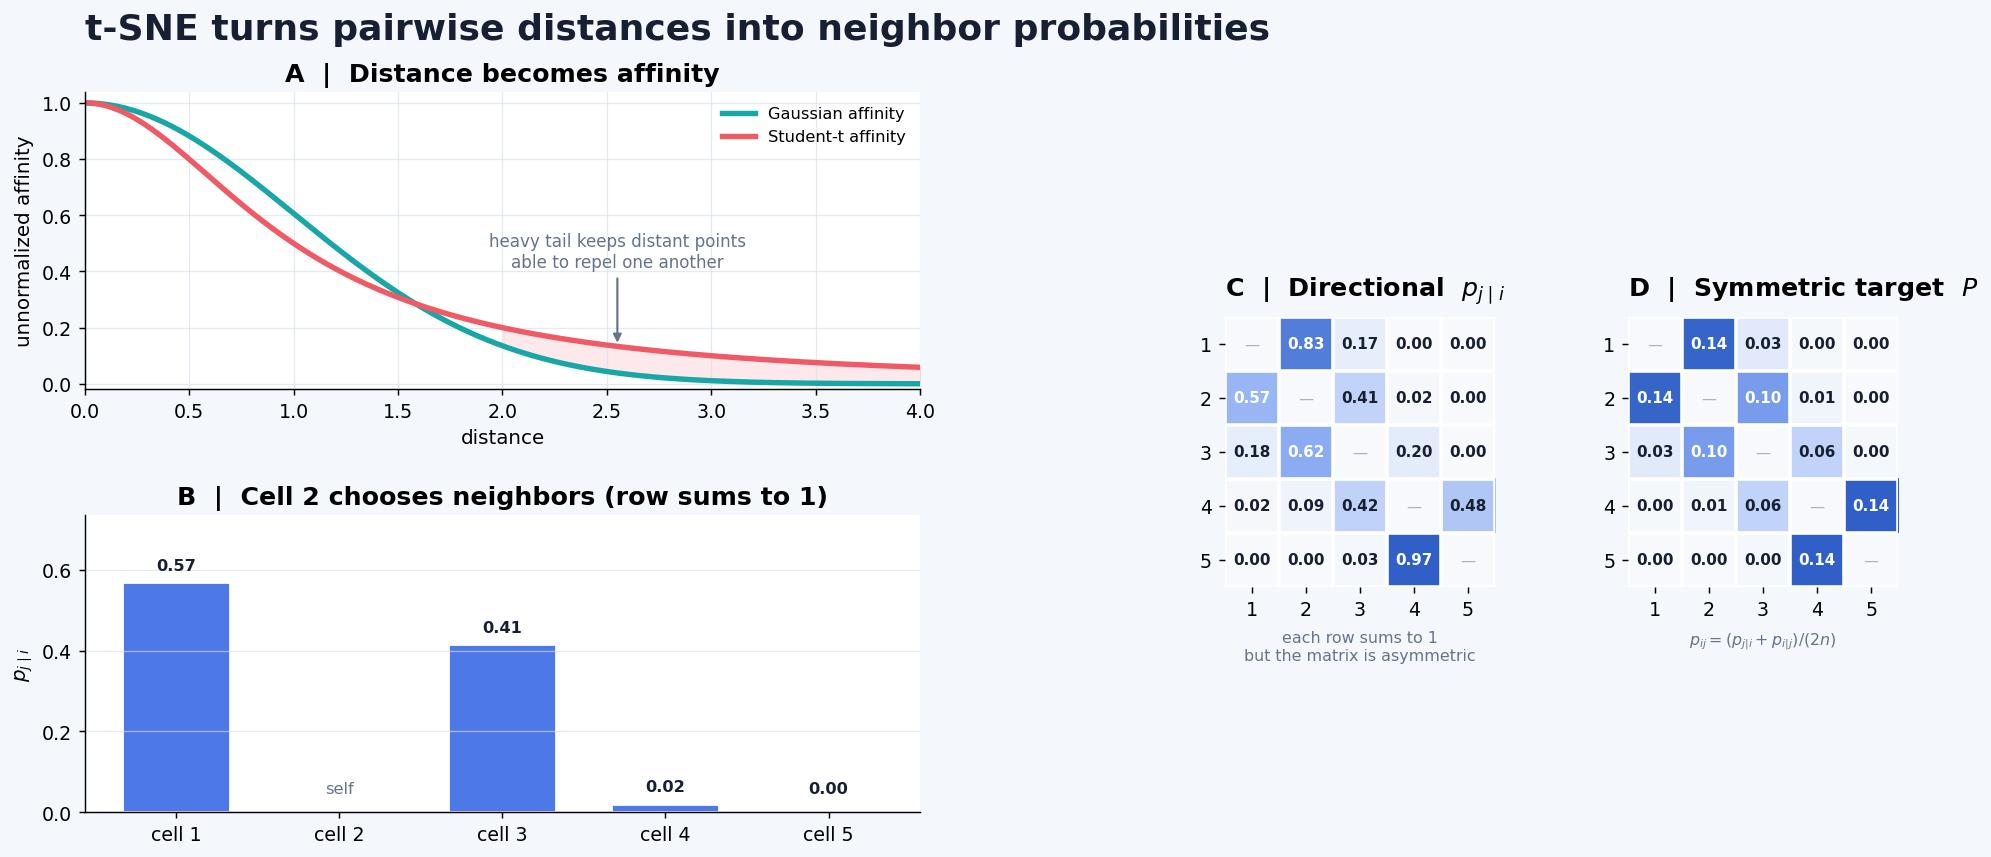

In [5]:
# Visual audit: Gaussian neighborhoods -> symmetric P; Student-t distances -> Q
from pathlib import Path
import runpy

similarity_candidates = [
    Path("tsne-similarity-kernels.py"),
    Path("codes/tsne-similarity-kernels.py"),
]
similarity_path = next((path for path in similarity_candidates if path.exists()), None)
if similarity_path is None:
    raise FileNotFoundError("Could not locate tsne-similarity-kernels.py")

_ = runpy.run_path(str(similarity_path))


#### 2.1.2 Second ingredient: let the mismatch create the force

We now move the low-dimensional points so that $Q$ imitates the fixed target $P$. t-SNE measures their mismatch with

$$
C=\mathrm{KL}(P\Vert Q)
=\sum_{i\ne j}p_{ij}\log\frac{p_{ij}}{q_{ij}}.
$$

This direction of KL strongly penalizes a pair that should be neighbors ($p_{ij}$ large) but is missing from the map ($q_{ij}$ small). Its gradient is

$$
\frac{\partial C}{\partial y_i}
=4\sum_{j\ne i}(p_{ij}-q_{ij})
\frac{y_i-y_j}{1+\lVert y_i-y_j\rVert^2}.
$$

After subtracting this gradient:

- $p_{ij}>q_{ij}$: the map has put a true neighbor too far away $\rightarrow$ **attraction**;
- $q_{ij}>p_{ij}$: the map has made a pair too similar $\rightarrow$ **repulsion**.

The selector below keeps the high-dimensional target $P$ fixed and compares two **low-dimensional** similarity models:

$$
q_{ij}^{(G)}\propto \exp(-\lVert y_i-y_j\rVert^2),
\qquad
q_{ij}^{(t)}\propto (1+\lVert y_i-y_j\rVert^2)^{-1}.
$$

The Gaussian comparison applies the mismatch force uniformly and therefore makes local points collapse very early. The Cauchy animation makes its near-attraction and far-repulsion brakes deliberately visible, so we can see cluster separation develop without immediately crushing all within-cluster structure. This is a teaching emphasis; in exact t-SNE, $P$ still stays fixed and the Cauchy factor enters $Q$ and the gradient above.

Switch kernels, then click one step at a time. Watch the embedding, the matrix $Q$, and the pairwise probability profile change together. We are matching **probability distributions induced by distances**, not raw distance histograms.


In [6]:
# Interactive KL optimization: click once, recompute Q, and move Y
from pathlib import Path
from IPython.display import HTML, display

kl_demo_candidates = [
    Path("tsne-kl-optimization-demo.html"),
    Path("codes/tsne-kl-optimization-demo.html"),
]
kl_demo_path = next((path for path in kl_demo_candidates if path.exists()), None)
if kl_demo_path is None:
    raise FileNotFoundError("Could not locate tsne-kl-optimization-demo.html")

display(HTML(kl_demo_path.read_text(encoding="utf-8")))


#### Play around: real PBMC cells

This time every dot is a real peripheral-blood cell and color is an annotated cell type. Your task is to turn the first 30 PCs into a two-dimensional representation.

Use `run_tsne(features, perplexity=30, random_state=7)`. It returns an array with shape `(n_cells, 2)`. Only the TODO line is missing; all loading and plotting code is ready. After it works, try changing `PERPLEXITY` to 10 or 60.

Data: processed PBMC3K from the [Besca example-data record](https://doi.org/10.5281/zenodo.3752813), derived from the 10x Genomics / Seurat PBMC3K tutorial.

In [7]:
# Download once, then read real PCA/t-SNE coordinates and cell-type labels
from pathlib import Path
import importlib
import runpy
import subprocess
import sys

try:
    import h5py
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "h5py"])
    h5py = importlib.import_module("h5py")

tutorial_candidates = [Path.cwd(), Path.cwd() / "codes"]
tutorial_dir = next(
    (path for path in tutorial_candidates if (path / "pbmc_playground.py").exists()),
    None,
)
if tutorial_dir is None:
    raise FileNotFoundError("Could not locate codes/pbmc_playground.py")

playground_api = runpy.run_path(str(tutorial_dir / "pbmc_playground.py"))
load_pbmc3k = playground_api["load_pbmc3k"]
run_pca = playground_api["run_pca"]
run_tsne = playground_api["run_tsne"]
cell_type_order = playground_api["CELL_TYPE_ORDER"]
pbmc_palette = playground_api["PBMC_PALETTE"]
pbmc_play = load_pbmc3k(tutorial_dir.parent / "data")
download_note = "downloaded" if pbmc_play["downloaded"] else "loaded from cache"
print(f"PBMC3K {download_note}: {len(pbmc_play['cell_type']):,} cells, 7 annotated cell types")


PBMC3K loaded from cache: 2,279 cells, 7 annotated cell types


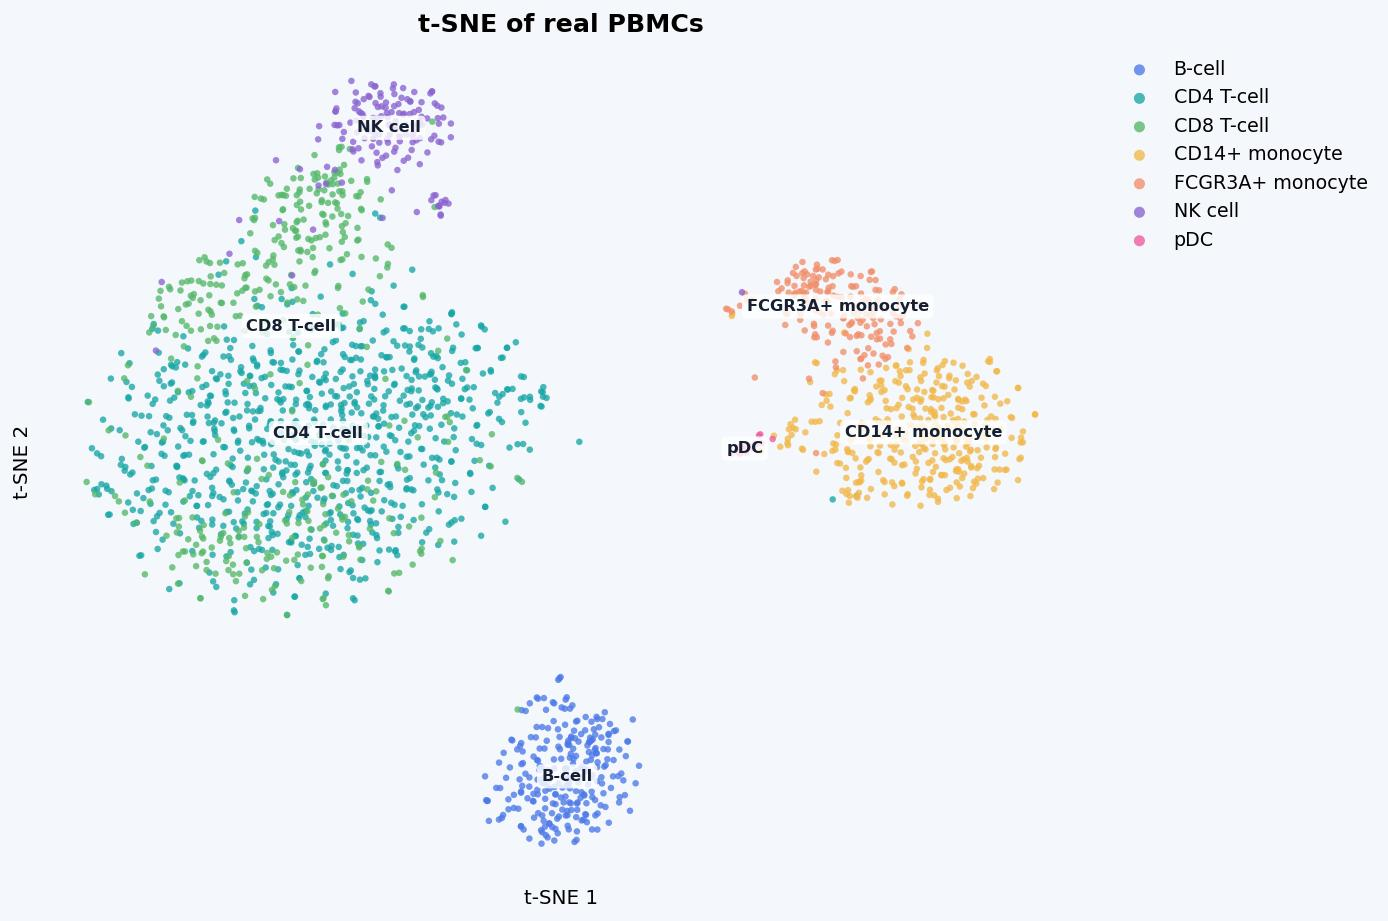

In [8]:
# Try changing 30 to 10 or 60 after the first successful run
PERPLEXITY = 30
POINT_SIZE = 13
ALPHA = 0.78
LABEL_CLUSTERS = True
CELL_TYPES = None  # e.g. ["B-cell", "NK cell", "CD4 T-cell"]

labels = np.asarray(pbmc_play["cell_type"])
tsne_input = np.asarray(pbmc_play["pca"][:, :30])
# TODO: implement task: create tsne_coordinates with run_tsne(...)

selected_types = cell_type_order if CELL_TYPES is None else CELL_TYPES

fig, ax = plt.subplots(figsize=(10.8, 7.2), facecolor="#F4F7FB")
ax.set_facecolor("#F4F7FB")
for cell_type in selected_types:
    mask = labels == cell_type
    ax.scatter(
        tsne_coordinates[mask, 0], tsne_coordinates[mask, 1],
        s=POINT_SIZE, alpha=ALPHA, color=pbmc_palette[cell_type],
        edgecolors="none", label=cell_type,
    )
    if LABEL_CLUSTERS and np.any(mask):
        center = np.median(tsne_coordinates[mask], axis=0)
        ax.text(
            center[0], center[1], cell_type, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#172033",
            bbox=dict(boxstyle="round,pad=0.28", fc="white", ec="none", alpha=0.82),
        )

ax.set(title="t-SNE of real PBMCs", xlabel="t-SNE 1", ylabel="t-SNE 2")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.7)
plt.tight_layout()
plt.show()


## Chapter 3. 

### 3.1 Principal Component Analysis

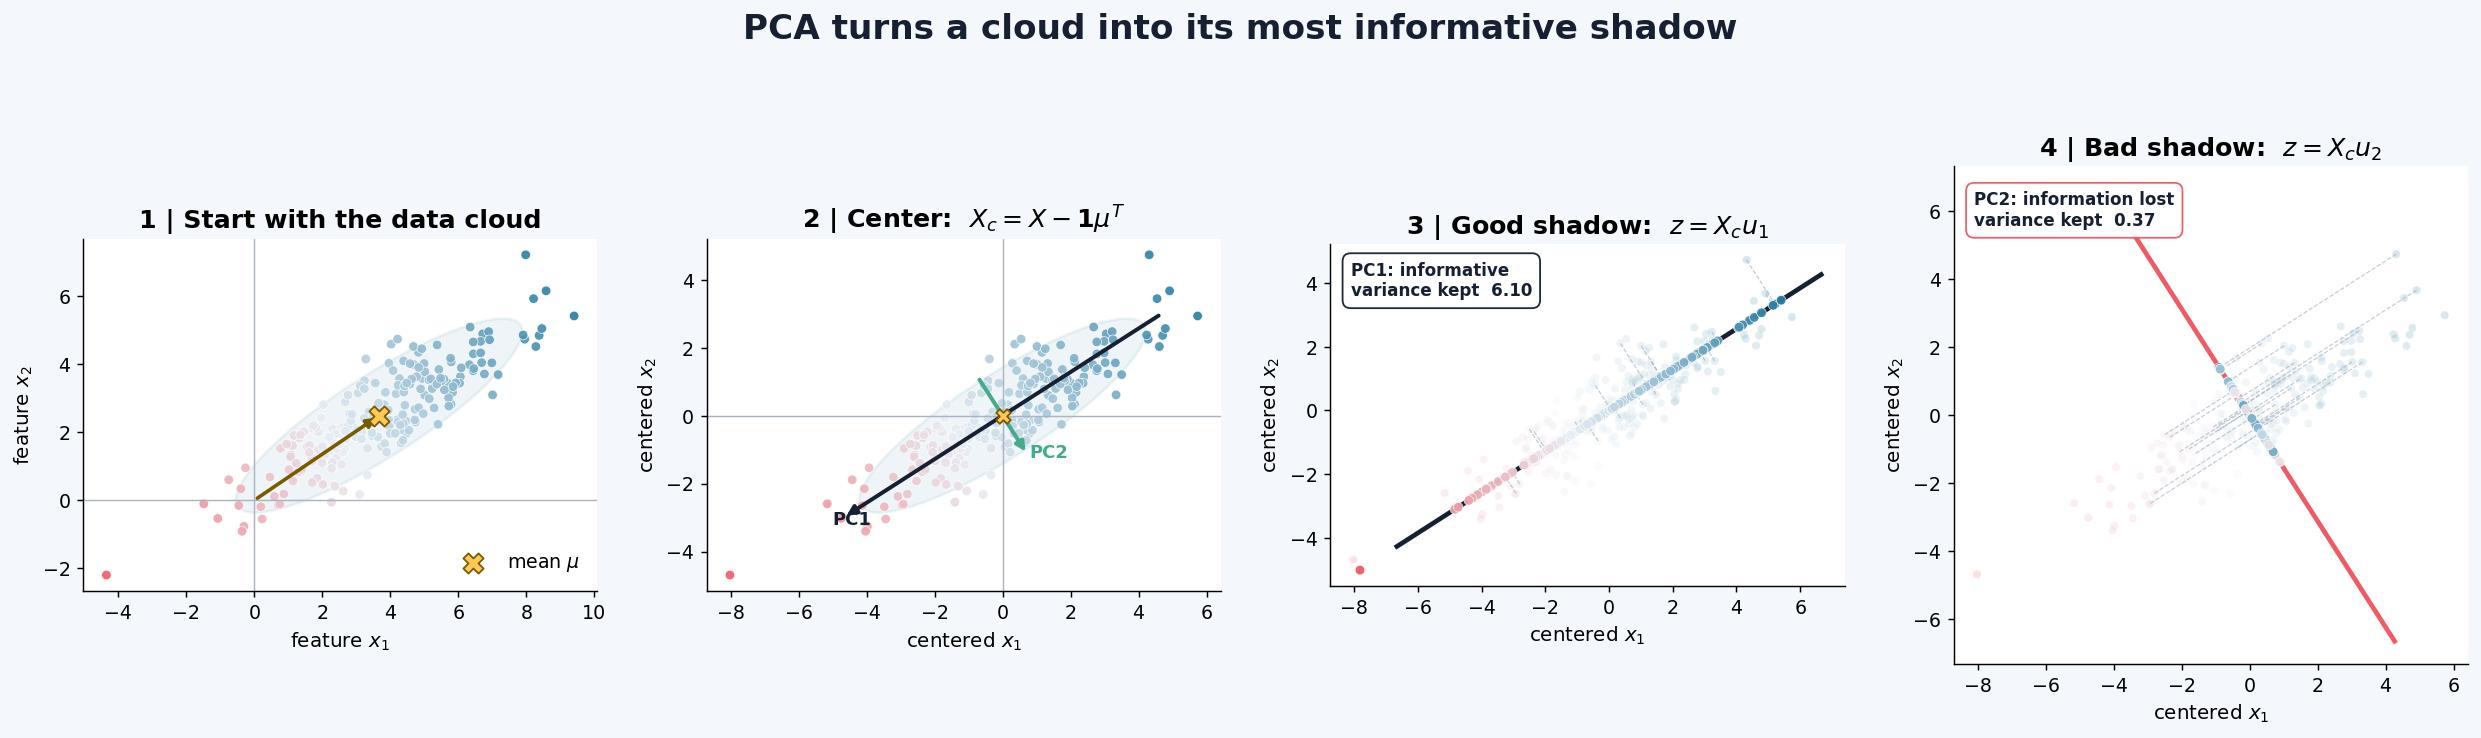

In [9]:
# PCA intuition I: center the cloud, then compare an informative and a poor shadow
from matplotlib.patches import Ellipse

rng_pca = np.random.default_rng(2026)
rotation_angle = np.deg2rad(32)
rotation = np.array([
    [np.cos(rotation_angle), -np.sin(rotation_angle)],
    [np.sin(rotation_angle),  np.cos(rotation_angle)],
])
latent_cloud = rng_pca.normal(size=(220, 2)) * np.array([2.45, 0.56])
X_pca_demo = latent_cloud @ rotation.T + np.array([3.6, 2.4])
demo_mean = X_pca_demo.mean(axis=0)
X_pca_centered = X_pca_demo - demo_mean
demo_covariance = X_pca_centered.T @ X_pca_centered / len(X_pca_centered)
demo_eigenvalues, demo_eigenvectors = np.linalg.eigh(demo_covariance)
eigen_order = np.argsort(demo_eigenvalues)[::-1]
demo_eigenvalues = demo_eigenvalues[eigen_order]
demo_eigenvectors = demo_eigenvectors[:, eigen_order]
pc1_vector, pc2_vector = demo_eigenvectors[:, 0], demo_eigenvectors[:, 1]

good_scores = X_pca_centered @ pc1_vector
bad_scores = X_pca_centered @ pc2_vector
good_projection = np.outer(good_scores, pc1_vector)
bad_projection = np.outer(bad_scores, pc2_vector)

pca_score_cmap = LinearSegmentedColormap.from_list(
    "pca_score", ["#277DA1", "#E8EDF5", "#F05A67"]
)
score_norm = plt.Normalize(good_scores.min(), good_scores.max())
demo_colors = pca_score_cmap(score_norm(good_scores))

def add_covariance_ellipse(ax, center, covariance, n_std=2.0):
    values, vectors = np.linalg.eigh(covariance)
    order = np.argsort(values)[::-1]
    values, vectors = values[order], vectors[:, order]
    angle = np.degrees(np.arctan2(vectors[1, 0], vectors[0, 0]))
    ellipse = Ellipse(
        center,
        2 * n_std * np.sqrt(values[0]),
        2 * n_std * np.sqrt(values[1]),
        angle=angle,
        facecolor="#277DA1",
        edgecolor="#277DA1",
        alpha=0.08,
        lw=1.5,
        zorder=0,
    )
    ax.add_patch(ellipse)

def draw_projection(ax, projected, direction, variance, line_color, title, verdict):
    ax.scatter(
        X_pca_centered[:, 0], X_pca_centered[:, 1],
        c=demo_colors, s=20, edgecolors="white", linewidths=0.3, alpha=0.18,
    )
    projection_subset = np.arange(0, len(X_pca_centered), 8)
    for idx in projection_subset:
        ax.plot(
            [X_pca_centered[idx, 0], projected[idx, 0]],
            [X_pca_centered[idx, 1], projected[idx, 1]],
            color="#9AA5B5", lw=0.65, ls="--", alpha=0.58, zorder=1,
        )
    ax.scatter(
        projected[:, 0], projected[:, 1],
        c=demo_colors, s=28, edgecolors="white", linewidths=0.35,
        alpha=0.95, zorder=3,
    )
    line_extent = np.sqrt(demo_eigenvalues[0]) * 3.2
    line_points = np.vstack([-direction * line_extent, direction * line_extent])
    ax.plot(line_points[:, 0], line_points[:, 1], color=line_color, lw=2.6)
    ax.text(
        0.04, 0.95,
        f"{verdict}\nvariance kept  {variance:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9.3,
        color="#172033", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.48", fc="white", ec=line_color, alpha=0.96),
    )
    ax.set(title=title, xlabel=r"centered $x_1$", ylabel=r"centered $x_2$")

fig, axes = plt.subplots(1, 4, figsize=(19.2, 5.35), facecolor="#F4F7FB")
ax_raw, ax_center, ax_good, ax_bad = axes

ax_raw.scatter(
    X_pca_demo[:, 0], X_pca_demo[:, 1], c=demo_colors, s=28,
    edgecolors="white", linewidths=0.4, alpha=0.90,
)
add_covariance_ellipse(ax_raw, demo_mean, demo_covariance)
ax_raw.scatter(
    *demo_mean, s=125, marker="X", c="#FFC857", edgecolors="#7A5A00",
    linewidths=1.0, zorder=5, label=r"mean $\mu$",
)
ax_raw.annotate(
    "", xy=demo_mean, xytext=(0, 0),
    arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#7A5A00"),
)
ax_raw.axhline(0, color="#AAB4C4", lw=0.8)
ax_raw.axvline(0, color="#AAB4C4", lw=0.8)
ax_raw.set(title="1 | Start with the data cloud", xlabel=r"feature $x_1$", ylabel=r"feature $x_2$")
ax_raw.legend(frameon=False, loc="lower right")

ax_center.scatter(
    X_pca_centered[:, 0], X_pca_centered[:, 1], c=demo_colors, s=28,
    edgecolors="white", linewidths=0.4, alpha=0.90,
)
add_covariance_ellipse(ax_center, np.zeros(2), demo_covariance)
ax_center.scatter(0, 0, s=65, marker="X", c="#FFC857", edgecolors="#7A5A00", zorder=5)
axis_scale = 2.25
for vector, value, color, label in zip(
    demo_eigenvectors.T, demo_eigenvalues, ["#172033", "#43AA8B"], ["PC1", "PC2"]
):
    endpoint = vector * np.sqrt(value) * axis_scale
    ax_center.annotate(
        "", xy=endpoint, xytext=-endpoint,
        arrowprops=dict(arrowstyle="-|>", lw=2.2, color=color),
    )
    ax_center.text(*(endpoint * 1.07), label, color=color, fontweight="bold", fontsize=10)
ax_center.axhline(0, color="#AAB4C4", lw=0.8)
ax_center.axvline(0, color="#AAB4C4", lw=0.8)
ax_center.set(
    title=r"2 | Center:  $X_c=X-\mathbf{1}\mu^T$",
    xlabel=r"centered $x_1$", ylabel=r"centered $x_2$",
)

draw_projection(
    ax_good, good_projection, pc1_vector, demo_eigenvalues[0], "#172033",
    r"3 | Good shadow:  $z=X_cu_1$", "PC1: informative",
)
draw_projection(
    ax_bad, bad_projection, pc2_vector, demo_eigenvalues[1], "#F05A67",
    r"4 | Bad shadow:  $z=X_cu_2$", "PC2: information lost",
)

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
fig.suptitle(
    "PCA turns a cloud into its most informative shadow",
    y=0.995, fontsize=19, fontweight="bold", color="#172033",
)
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()


PCA intuitively finds the best low dimension line to project the data on, while preserving the most sample information (heterogeneity). At least you don't want to blur the red points with the blue points.

#### From projection to an optimization problem

Let the sample mean and centered matrix be

$$
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i,
\qquad
X_c=X-\mathbf{1}\mu^T.
$$

Choose a unit direction $u\in\mathbb{R}^d$, with $u^Tu=1$. Project every observation onto that direction:

$$
z=X_cu.
$$

Because $X_c$ is centered, the mean of $z$ is zero. Its sample variance is

$$
\operatorname{Var}(z)
=\frac{1}{n-1}z^Tz
=\frac{1}{n-1}u^TX_c^TX_cu
=u^TSu,
$$

where

$$
S=\frac{1}{n-1}X_c^TX_c
$$

is the covariance matrix. PCA therefore solves the Rayleigh-quotient problem

$$
\boxed{\quad u_1=\arg\max_{u^Tu=1} u^TSu \quad}.
$$


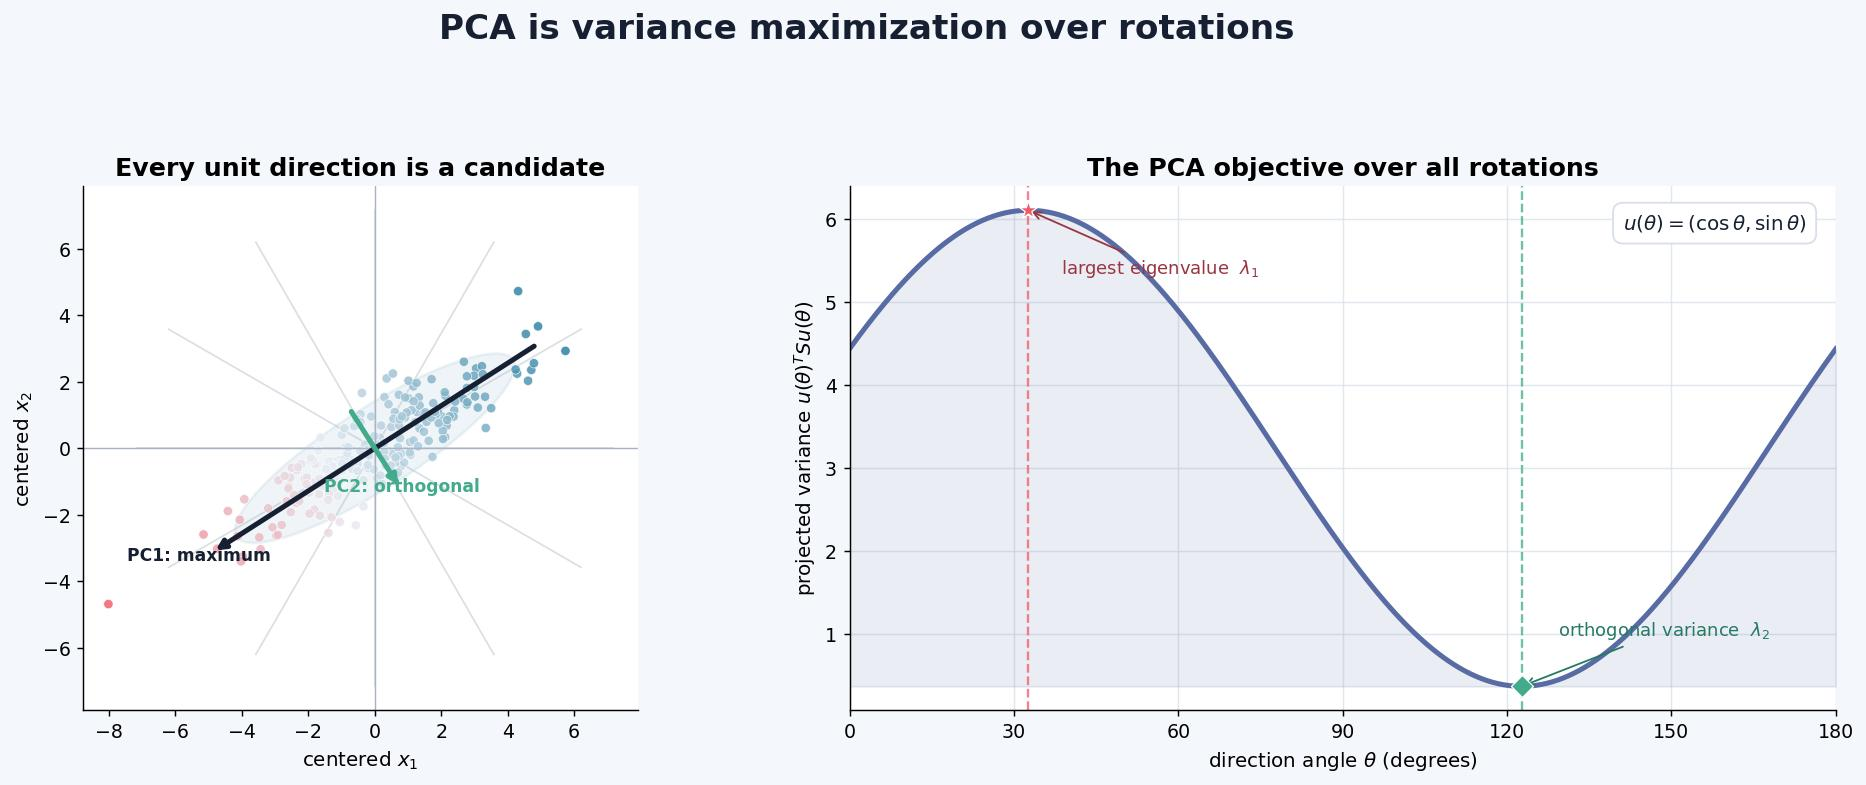

In [10]:
# PCA intuition II: scan every possible direction and watch projected variance peak at PC1
theta = np.linspace(0, np.pi, 721)
candidate_directions = np.c_[np.cos(theta), np.sin(theta)]
directional_variance = np.einsum(
    "ij,jk,ik->i", candidate_directions, demo_covariance, candidate_directions
)
pc1_angle = np.mod(np.arctan2(pc1_vector[1], pc1_vector[0]), np.pi)
pc2_angle = np.mod(pc1_angle + np.pi / 2, np.pi)

fig, (ax_geometry, ax_objective) = plt.subplots(
    1, 2, figsize=(15.5, 6.0), facecolor="#F4F7FB", gridspec_kw={"width_ratios": [1, 1.18]}
)
ax_geometry.scatter(X_pca_centered[:, 0], X_pca_centered[:, 1], c=demo_colors,
                    s=27, edgecolors="white", linewidths=0.4, alpha=0.82)
add_covariance_ellipse(ax_geometry, np.zeros(2), demo_covariance)
candidate_extent = np.sqrt(demo_eigenvalues[0]) * 2.9
for angle_deg in (0, 30, 60, 90, 120, 150):
    vector = np.array([np.cos(np.deg2rad(angle_deg)), np.sin(np.deg2rad(angle_deg))])
    endpoints = np.vstack([-vector, vector]) * candidate_extent
    ax_geometry.plot(endpoints[:, 0], endpoints[:, 1], color="#AAB4C4", lw=1.0,
                     alpha=0.42, zorder=0)
for vector, value, color, label in zip(
    [pc1_vector, pc2_vector], demo_eigenvalues, ["#172033", "#43AA8B"], ["PC1: maximum", "PC2: orthogonal"]
):
    endpoint = vector * np.sqrt(value) * 2.35
    ax_geometry.annotate("", xy=endpoint, xytext=-endpoint,
                         arrowprops=dict(arrowstyle="-|>", color=color, lw=2.8))
    ax_geometry.text(*(endpoint * 1.08), label, color=color, fontsize=9.5,
                     fontweight="bold", ha="center")
ax_geometry.axhline(0, color="#AAB4C4", lw=0.8)
ax_geometry.axvline(0, color="#AAB4C4", lw=0.8)
ax_geometry.set_aspect("equal", adjustable="box")
ax_geometry.set(xlabel=r"centered $x_1$", ylabel=r"centered $x_2$",
                title="Every unit direction is a candidate")

angles_deg = np.degrees(theta)
ax_objective.plot(angles_deg, directional_variance, color="#586BA4", lw=2.8)
ax_objective.fill_between(angles_deg, directional_variance, directional_variance.min(),
                          color="#586BA4", alpha=0.12)
ax_objective.scatter(np.degrees(pc1_angle), demo_eigenvalues[0], s=105, c="#F05A67",
                     marker="*", edgecolors="white", linewidths=0.7, zorder=5)
ax_objective.scatter(np.degrees(pc2_angle), demo_eigenvalues[1], s=75, c="#43AA8B",
                     marker="D", edgecolors="white", linewidths=0.7, zorder=5)
ax_objective.axvline(np.degrees(pc1_angle), color="#F05A67", lw=1.3, ls="--", alpha=0.75)
ax_objective.axvline(np.degrees(pc2_angle), color="#43AA8B", lw=1.3, ls="--", alpha=0.75)
ax_objective.annotate(r"largest eigenvalue  $\lambda_1$", (np.degrees(pc1_angle), demo_eigenvalues[0]),
                      xytext=(18, -35), textcoords="offset points", color="#9A3542", fontsize=10,
                      arrowprops=dict(arrowstyle="->", color="#9A3542"))
ax_objective.annotate(r"orthogonal variance  $\lambda_2$", (np.degrees(pc2_angle), demo_eigenvalues[1]),
                      xytext=(20, 28), textcoords="offset points", color="#267A64", fontsize=10,
                      arrowprops=dict(arrowstyle="->", color="#267A64"))
ax_objective.set_xlim(0, 180)
ax_objective.set_xticks(np.arange(0, 181, 30))
ax_objective.set(xlabel=r"direction angle $\theta$ (degrees)",
                 ylabel=r"projected variance $u(\theta)^T S u(\theta)$",
                 title="The PCA objective over all rotations")
ax_objective.grid(color="#D8DFEA", lw=0.8, alpha=0.75)
ax_objective.set_axisbelow(True)
ax_objective.text(0.97, 0.95, r"$u(\theta)=(\cos\theta,\sin\theta)$",
                  transform=ax_objective.transAxes, ha="right", va="top", fontsize=11,
                  color="#172033", bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#D8DFEA"))

fig.suptitle("PCA is variance maximization over rotations",
             y=1.00, fontsize=19, fontweight="bold", color="#172033")
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

#### Solving the constrained problem

Introduce a Lagrange multiplier for the unit-length constraint:

$$
\mathcal{L}(u,\lambda)=u^TSu-\lambda(u^Tu-1).
$$

Set the gradient with respect to $u$ to zero:

$$
\nabla_u\mathcal{L}=2Su-2\lambda u=0
\quad\Longrightarrow\quad
\boxed{Su=\lambda u}.
$$

Therefore the principal directions are eigenvectors of the covariance matrix. The variance along an
eigenvector is its eigenvalue, so PC1 is the eigenvector with the largest eigenvalue. Later components
repeat the same search inside the space orthogonal to every direction already selected:

$$
u_k=\arg\max_{\|u\|_2=1,\;u^Tu_j=0\;(j<k)}u^TSu.
$$

In computation we usually avoid constructing $S$ and use the singular value decomposition directly:

$$
X_c=U\Sigma V^T,
\qquad
V=[u_1,\ldots,u_d].
$$

The columns of $V$ are the principal directions, the score matrix is $Z=U\Sigma=X_cV$, and the
explained variance of component $j$ is

$$
\lambda_j=\frac{\sigma_j^2}{n-1}.
$$


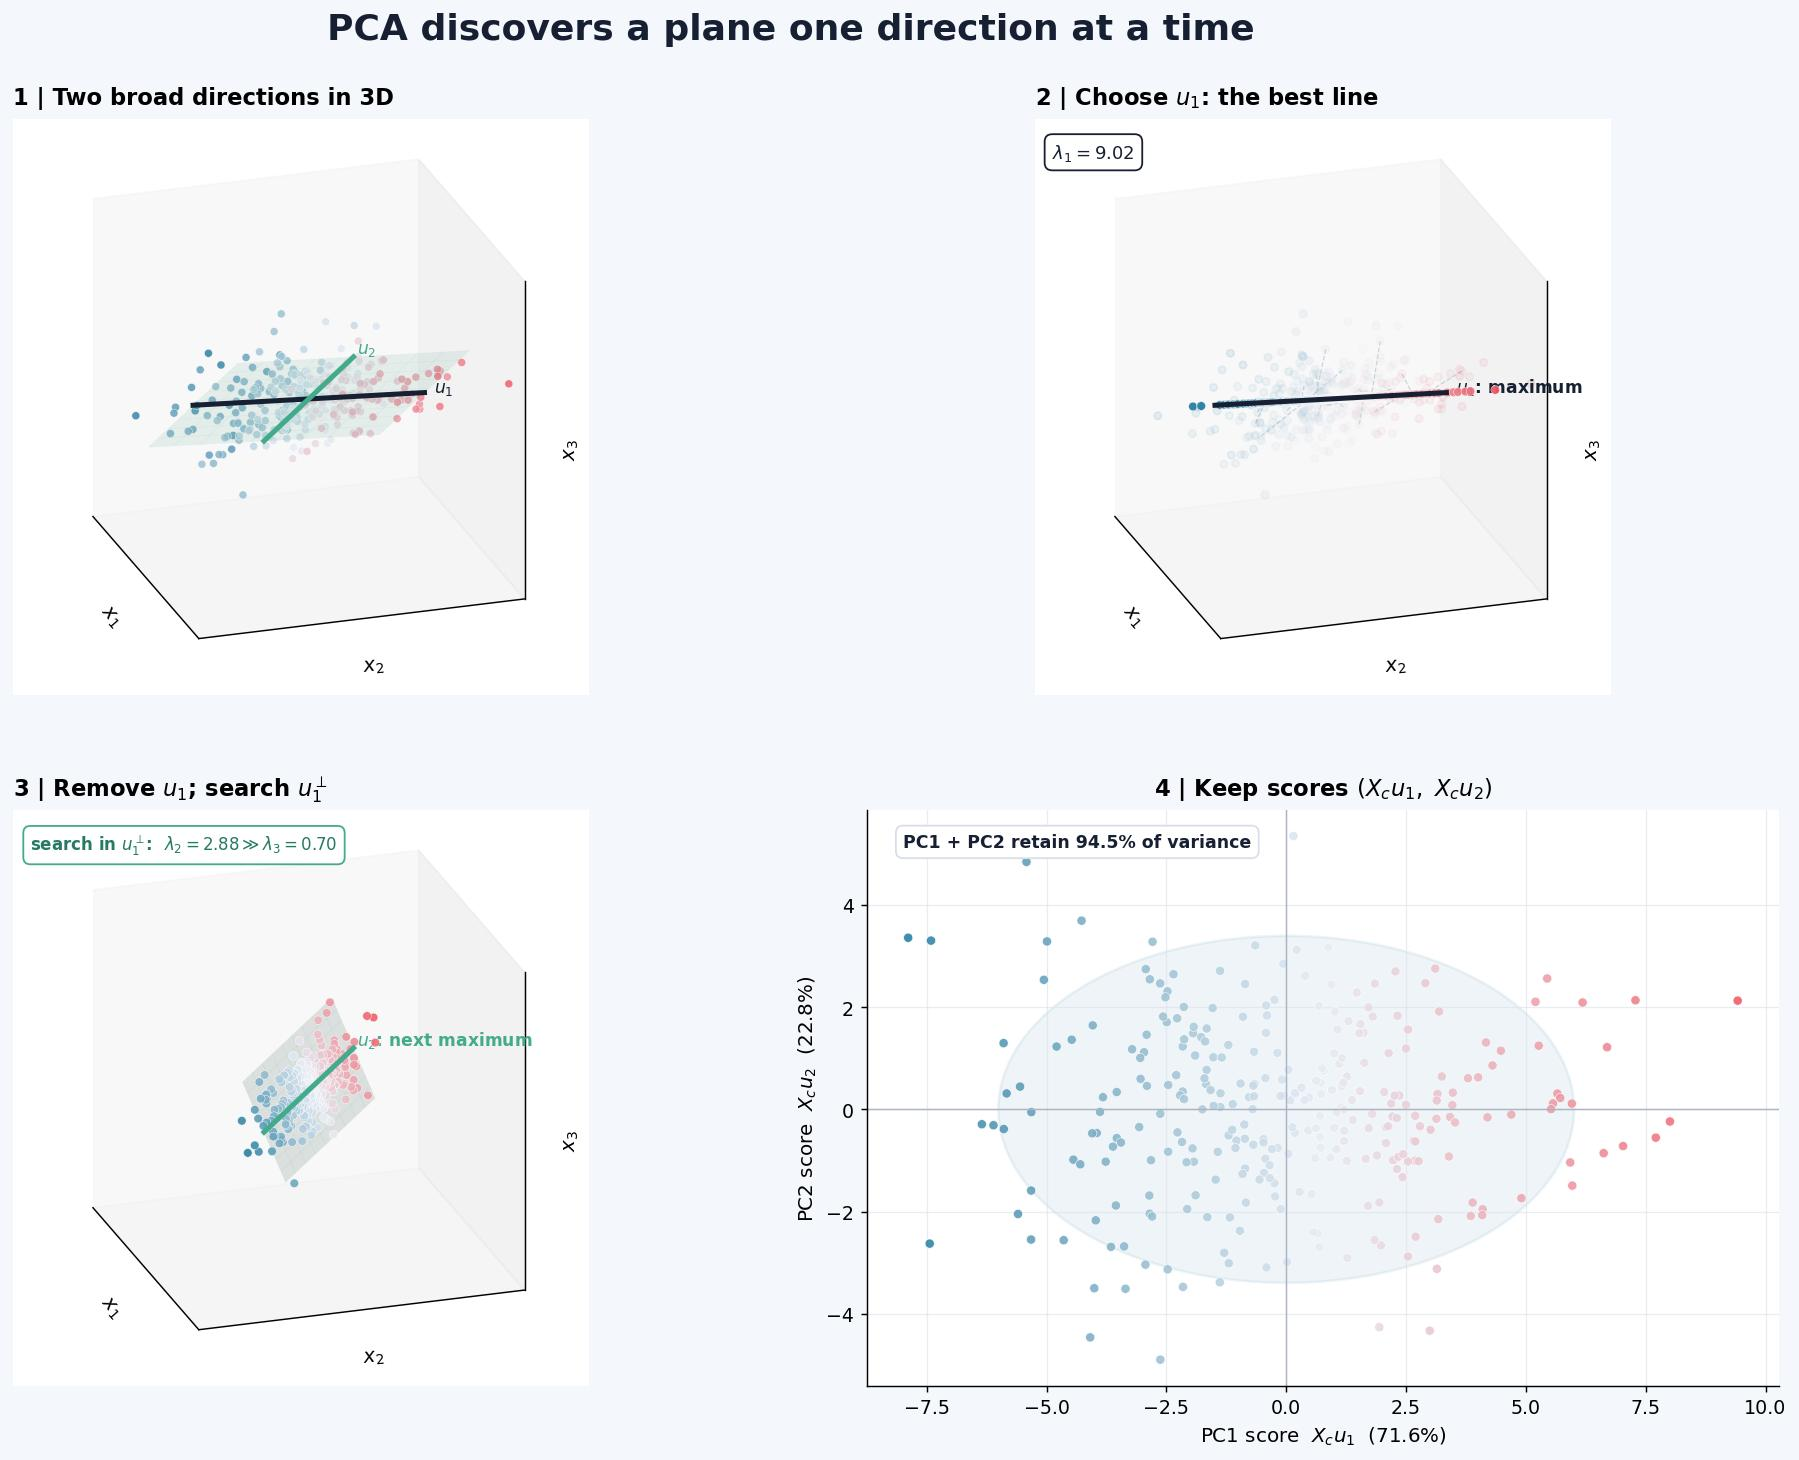

In [11]:
# PCA intuition III: discover a two-dimensional representation one orthogonal direction at a time
rng_reconstruction = np.random.default_rng(314)

# Construct a 3D cloud with two broad directions and one thin direction.
seed_u1 = np.array([1.00, 0.55, 0.30])
seed_u1 = seed_u1 / np.linalg.norm(seed_u1)
seed_u2 = np.array([-0.45, 0.88, 0.25])
seed_u2 = seed_u2 - seed_u1 * (seed_u2 @ seed_u1)
seed_u2 = seed_u2 / np.linalg.norm(seed_u2)
seed_u3 = np.cross(seed_u1, seed_u2)
generating_basis = np.column_stack([seed_u1, seed_u2, seed_u3])

latent_3d = rng_reconstruction.normal(size=(300, 3)) * np.array([3.10, 1.70, 0.90])
X_3d_centered = latent_3d @ generating_basis.T
X_3d_centered -= X_3d_centered.mean(axis=0)

U_3d, sigma_3d, Vt_3d = np.linalg.svd(X_3d_centered, full_matrices=False)
scores_3d = U_3d * sigma_3d
u1_3d, u2_3d, u3_3d = Vt_3d
variance_3d = sigma_3d ** 2 / (len(X_3d_centered) - 1)
variance_ratio_3d = variance_3d / variance_3d.sum()

projection_u1 = np.outer(scores_3d[:, 0], u1_3d)
residual_after_u1 = X_3d_centered - projection_u1
representation_2d = scores_3d[:, :2]

color_pc1 = pca_score_cmap(
    plt.Normalize(scores_3d[:, 0].min(), scores_3d[:, 0].max())(scores_3d[:, 0])
)
color_pc2 = pca_score_cmap(
    plt.Normalize(scores_3d[:, 1].min(), scores_3d[:, 1].max())(scores_3d[:, 1])
)

def plane_coordinates(direction_a, direction_b, extent_a, extent_b, density=10):
    coordinate_a = np.linspace(-extent_a, extent_a, density)
    coordinate_b = np.linspace(-extent_b, extent_b, density)
    coordinate_a, coordinate_b = np.meshgrid(coordinate_a, coordinate_b)
    return (
        coordinate_a[..., None] * direction_a
        + coordinate_b[..., None] * direction_b
    )

def draw_direction_3d(ax, direction, extent, color, label, linewidth=2.8):
    endpoints = np.vstack([-direction * extent, direction * extent])
    ax.plot(*endpoints.T, color=color, lw=linewidth, zorder=5)
    ax.text(
        *(direction * extent * 1.08), label,
        color=color, fontweight="bold", fontsize=9.5,
    )

fig = plt.figure(figsize=(16.0, 11.4), facecolor="#F4F7FB")
gs = fig.add_gridspec(
    2, 2, left=0.045, right=0.975, bottom=0.055, top=0.91,
    hspace=0.20, wspace=0.12,
)
ax_cloud = fig.add_subplot(gs[0, 0], projection="3d")
ax_first = fig.add_subplot(gs[0, 1], projection="3d")
ax_residual = fig.add_subplot(gs[1, 0], projection="3d")
ax_scores = fig.add_subplot(gs[1, 1])

extent_u1 = np.percentile(np.abs(scores_3d[:, 0]), 97)
extent_u2 = np.percentile(np.abs(scores_3d[:, 1]), 97)
extent_u3 = max(np.percentile(np.abs(scores_3d[:, 2]), 97), 0.55)
rank2_plane = plane_coordinates(u1_3d, u2_3d, extent_u1, extent_u2)

# 1. Reveal that the cloud is broad along a plane, not along all three dimensions.
ax_cloud.plot_surface(
    rank2_plane[..., 0], rank2_plane[..., 1], rank2_plane[..., 2],
    color="#43AA8B", alpha=0.10, edgecolor="#A7D8CA", linewidth=0.35,
)
ax_cloud.scatter(
    *X_3d_centered.T, c=color_pc1, s=20, edgecolors="white",
    linewidths=0.28, alpha=0.82, depthshade=False,
)
draw_direction_3d(ax_cloud, u1_3d, extent_u1, "#172033", r"$u_1$")
draw_direction_3d(ax_cloud, u2_3d, extent_u2, "#43AA8B", r"$u_2$")
ax_cloud.set_title("1 | Two broad directions in 3D", loc="left", pad=8, fontsize=12.5)

# 2. First search: all unit directions are allowed; u1 keeps the most variance.
ax_first.scatter(
    *X_3d_centered.T, c=color_pc1, s=17, alpha=0.10, depthshade=False,
)
connector_subset = np.arange(0, len(X_3d_centered), 12)
for idx in connector_subset:
    ax_first.plot(
        [X_3d_centered[idx, 0], projection_u1[idx, 0]],
        [X_3d_centered[idx, 1], projection_u1[idx, 1]],
        [X_3d_centered[idx, 2], projection_u1[idx, 2]],
        color="#AAB4C4", lw=0.7, ls="--", alpha=0.55,
    )
ax_first.scatter(
    *projection_u1.T, c=color_pc1, s=23, edgecolors="white",
    linewidths=0.25, alpha=0.94, depthshade=False,
)
draw_direction_3d(ax_first, u1_3d, extent_u1, "#172033", r"$u_1$: maximum")
ax_first.text2D(
    0.03, 0.96,
    rf"$\lambda_1={variance_3d[0]:.2f}$",
    transform=ax_first.transAxes, ha="left", va="top",
    color="#172033", fontsize=10, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.42", fc="white", ec="#172033"),
)
ax_first.set_title(r"2 | Choose $u_1$: the best line", loc="left", pad=8, fontsize=12.5)

# 3. Remove u1. Every residual now lies in u1-perp; search that plane for u2.
orthogonal_plane = plane_coordinates(u2_3d, u3_3d, extent_u2, extent_u2 * 0.72)
ax_residual.plot_surface(
    orthogonal_plane[..., 0], orthogonal_plane[..., 1], orthogonal_plane[..., 2],
    color="#43AA8B", alpha=0.13, edgecolor="#A7D8CA", linewidth=0.40,
)
ax_residual.scatter(
    *residual_after_u1.T, c=color_pc2, s=23, edgecolors="white",
    linewidths=0.28, alpha=0.88, depthshade=False,
)
draw_direction_3d(ax_residual, u2_3d, extent_u2, "#43AA8B", r"$u_2$: next maximum")
ax_residual.text2D(
    0.03, 0.96,
    rf"search in $u_1^\perp$:  $\lambda_2={variance_3d[1]:.2f}\gg\lambda_3={variance_3d[2]:.2f}$",
    transform=ax_residual.transAxes, ha="left", va="top",
    color="#267A64", fontsize=9.2, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.42", fc="white", ec="#43AA8B"),
)
ax_residual.set_title(
    r"3 | Remove $u_1$; search $u_1^\perp$",
    loc="left", pad=8, fontsize=12.5,
)

# 4. The learned representation is simply each point's coordinates along u1 and u2.
ax_scores.scatter(
    representation_2d[:, 0], representation_2d[:, 1],
    c=color_pc1, s=26, edgecolors="white", linewidths=0.35, alpha=0.88,
)
add_covariance_ellipse(
    ax_scores, np.zeros(2), np.cov(representation_2d, rowvar=False), n_std=2.0,
)
ax_scores.axhline(0, color="#AAB4C4", lw=0.8)
ax_scores.axvline(0, color="#AAB4C4", lw=0.8)
retained_2d = 100 * variance_ratio_3d[:2].sum()
ax_scores.text(
    0.04, 0.96,
    f"PC1 + PC2 retain {retained_2d:.1f}% of variance",
    transform=ax_scores.transAxes, ha="left", va="top",
    color="#172033", fontsize=9.6, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.42", fc="white", ec="#D8DFEA"),
)
ax_scores.set(
    xlabel=rf"PC1 score  $X_cu_1$  ({100 * variance_ratio_3d[0]:.1f}%)",
    ylabel=rf"PC2 score  $X_cu_2$  ({100 * variance_ratio_3d[1]:.1f}%)",
)
ax_scores.set_title(r"4 | Keep scores $(X_cu_1,\ X_cu_2)$", fontsize=12.5, pad=8)
ax_scores.grid(color="#D8DFEA", lw=0.7, alpha=0.55)
ax_scores.set_axisbelow(True)

shared_limit = np.max(np.abs(X_3d_centered)) * 0.88
for ax in (ax_cloud, ax_first, ax_residual):
    ax.set_xlim(-shared_limit, shared_limit)
    ax.set_ylim(-shared_limit, shared_limit)
    ax.set_zlim(-shared_limit, shared_limit)
    ax.set_xlabel(r"$x_1$", labelpad=-3)
    ax.set_ylabel(r"$x_2$", labelpad=-3)
    ax.set_zlabel(r"$x_3$", labelpad=-3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_box_aspect((1, 1, 1))
    ax.set_proj_type("ortho")
    ax.grid(False)

# Keep one oblique camera across panels: both u1 and the u1-perpendicular plane remain visible.
for ax in (ax_cloud, ax_first, ax_residual):
    ax.view_init(elev=22, azim=-18)

fig.suptitle(
    "PCA discovers a plane one direction at a time",
    y=0.982, fontsize=20, fontweight="bold", color="#172033",
)
plt.show()


#### From the learned plane to reconstruction

The figure above constructs the representation sequentially:

$$
z_1=X_cu_1,
\qquad
z_2=X_cu_2,
\qquad
u_2\perp u_1.
$$

Stack the first $k$ directions as $V_k=[u_1,\ldots,u_k]$. The score and reconstruction matrices are

$$
Z_k=X_cV_k,
\qquad
\widehat{X}_{c,k}=Z_kV_k^T=U_k\Sigma_kV_k^T.
$$

Add the mean back to return to the original coordinates:

$$
\widehat{X}_k=\mathbf{1}\mu^T+U_k\Sigma_kV_k^T.
$$

The Eckart--Young theorem says this truncated SVD minimizes squared reconstruction error among all
rank-$k$ matrices:

$$
\widehat{X}_{c,k}
=\arg\min_{\operatorname{rank}(M)\leq k}\|X_c-M\|_F^2,
\qquad
\|X_c-\widehat{X}_{c,k}\|_F^2=\sum_{j>k}\sigma_j^2.
$$

**Practical note.** Covariance PCA is sensitive to measurement units. Center only when the feature scales
are scientifically comparable; z-score each feature before PCA when different units or ranges should
receive equal weight.


In [12]:
# Reproducible single-cell toy data used by the PCA audit below
rng_bio = np.random.default_rng(43803)

BG = "#F4F7FB"
INK = "#172033"
MUTED = "#5D687D"
GRID = "#D8DFEA"
ACTIVITY_COLOR = "#F8961E"

CELL_TYPES = np.array([
    "Astrocyte",
    "Excitatory neuron",
    "Inhibitory neuron",
    "Oligodendrocyte",
])
CELL_SHORT = np.array(["AST", "EXC", "INH", "OLI"])
CELL_COLORS = np.array(["#277DA1", "#F05A67", "#43AA8B", "#8F6BB3"])
ACTIVITY_NAME = "Shared hypoxia response"
PROGRAM_NAMES = np.concatenate([CELL_TYPES, [ACTIVITY_NAME]])
PROGRAM_SHORT = np.concatenate([CELL_SHORT, ["HYP"]])
PROGRAM_COLORS = np.concatenate([CELL_COLORS, [ACTIVITY_COLOR]])
N_IDENTITIES = len(CELL_TYPES)
N_PROGRAMS = len(PROGRAM_NAMES)

identity_markers = [
    ["AQP4", "SLC1A3", "GFAP", "ALDH1L1", "S100B", "GLUL", "SOX9", "GJA1"],
    ["SLC17A7", "SATB2", "CAMK2A", "TBR1", "GRIA2", "NEUROD6", "RORB", "BCL11B"],
    ["GAD1", "GAD2", "SLC6A1", "DLX1", "DLX2", "PVALB", "SST", "VIP"],
    ["MBP", "MOG", "PLP1", "OLIG1", "OLIG2", "SOX10", "MAG", "CNP"],
]
activity_markers = ["HIF1A", "VEGFA", "BNIP3", "DDIT4", "LDHA", "ENO1", "SLC2A1", "HMOX1"]
housekeeping = ["ACTB", "RPLP0", "EEF1A1", "B2M"]
GENE_NAMES = np.array(sum(identity_markers, []) + activity_markers + housekeeping)

# Each row is a nonnegative transcript-composition program.
H_true_raw = np.full((N_PROGRAMS, len(GENE_NAMES)), 0.012)
for k in range(N_IDENTITIES):
    marker_block = slice(8 * k, 8 * (k + 1))
    H_true_raw[k, marker_block] = rng_bio.lognormal(1.35, 0.22, 8)
    H_true_raw[k, 40:] = rng_bio.uniform(0.45, 0.90, 4)
H_true_raw[-1, :] = 0.004
H_true_raw[-1, 32:40] = rng_bio.lognormal(1.55, 0.20, 8)
H_true_raw[-1, 40:] = rng_bio.uniform(0.12, 0.24, 4)
H_true = H_true_raw / H_true_raw.sum(axis=1, keepdims=True)

n_singletons = 520
singleton_identity = np.tile(
    np.arange(N_IDENTITIES),
    int(np.ceil(n_singletons / N_IDENTITIES)),
)[:n_singletons]
rng_bio.shuffle(singleton_identity)

# A shared activity program is available to three of the four identities.
activity_eligible = np.isin(singleton_identity, [0, 1, 2])
singleton_active = activity_eligible & (rng_bio.random(n_singletons) < 0.30)
singleton_activity = np.zeros(n_singletons)
singleton_activity[singleton_active] = rng_bio.uniform(0.10, 0.70, singleton_active.sum())

W_singleton = np.zeros((n_singletons, N_PROGRAMS))
W_singleton[np.arange(n_singletons), singleton_identity] = 1.0 - singleton_activity
W_singleton[:, -1] = singleton_activity

library_singleton = rng_bio.lognormal(np.log(3400), 0.32, n_singletons)
mean_singleton = library_singleton[:, None] * (W_singleton @ H_true)
dispersion = 18.0
latent_rate = rng_bio.gamma(dispersion, mean_singleton / dispersion)
counts_singleton = rng_bio.poisson(latent_rate)

shuffle = rng_bio.permutation(n_singletons)
X_counts = counts_singleton[shuffle]
W_true = W_singleton[shuffle]
cell_identity = singleton_identity[shuffle]
activity_usage_true = W_true[:, -1]
active_cell = activity_usage_true > 0.02

observed_depth = np.maximum(X_counts.sum(axis=1), 1)
X_cp10k = X_counts / observed_depth[:, None] * 10_000
X_log = np.log1p(X_cp10k)
n_cells, n_genes = X_counts.shape


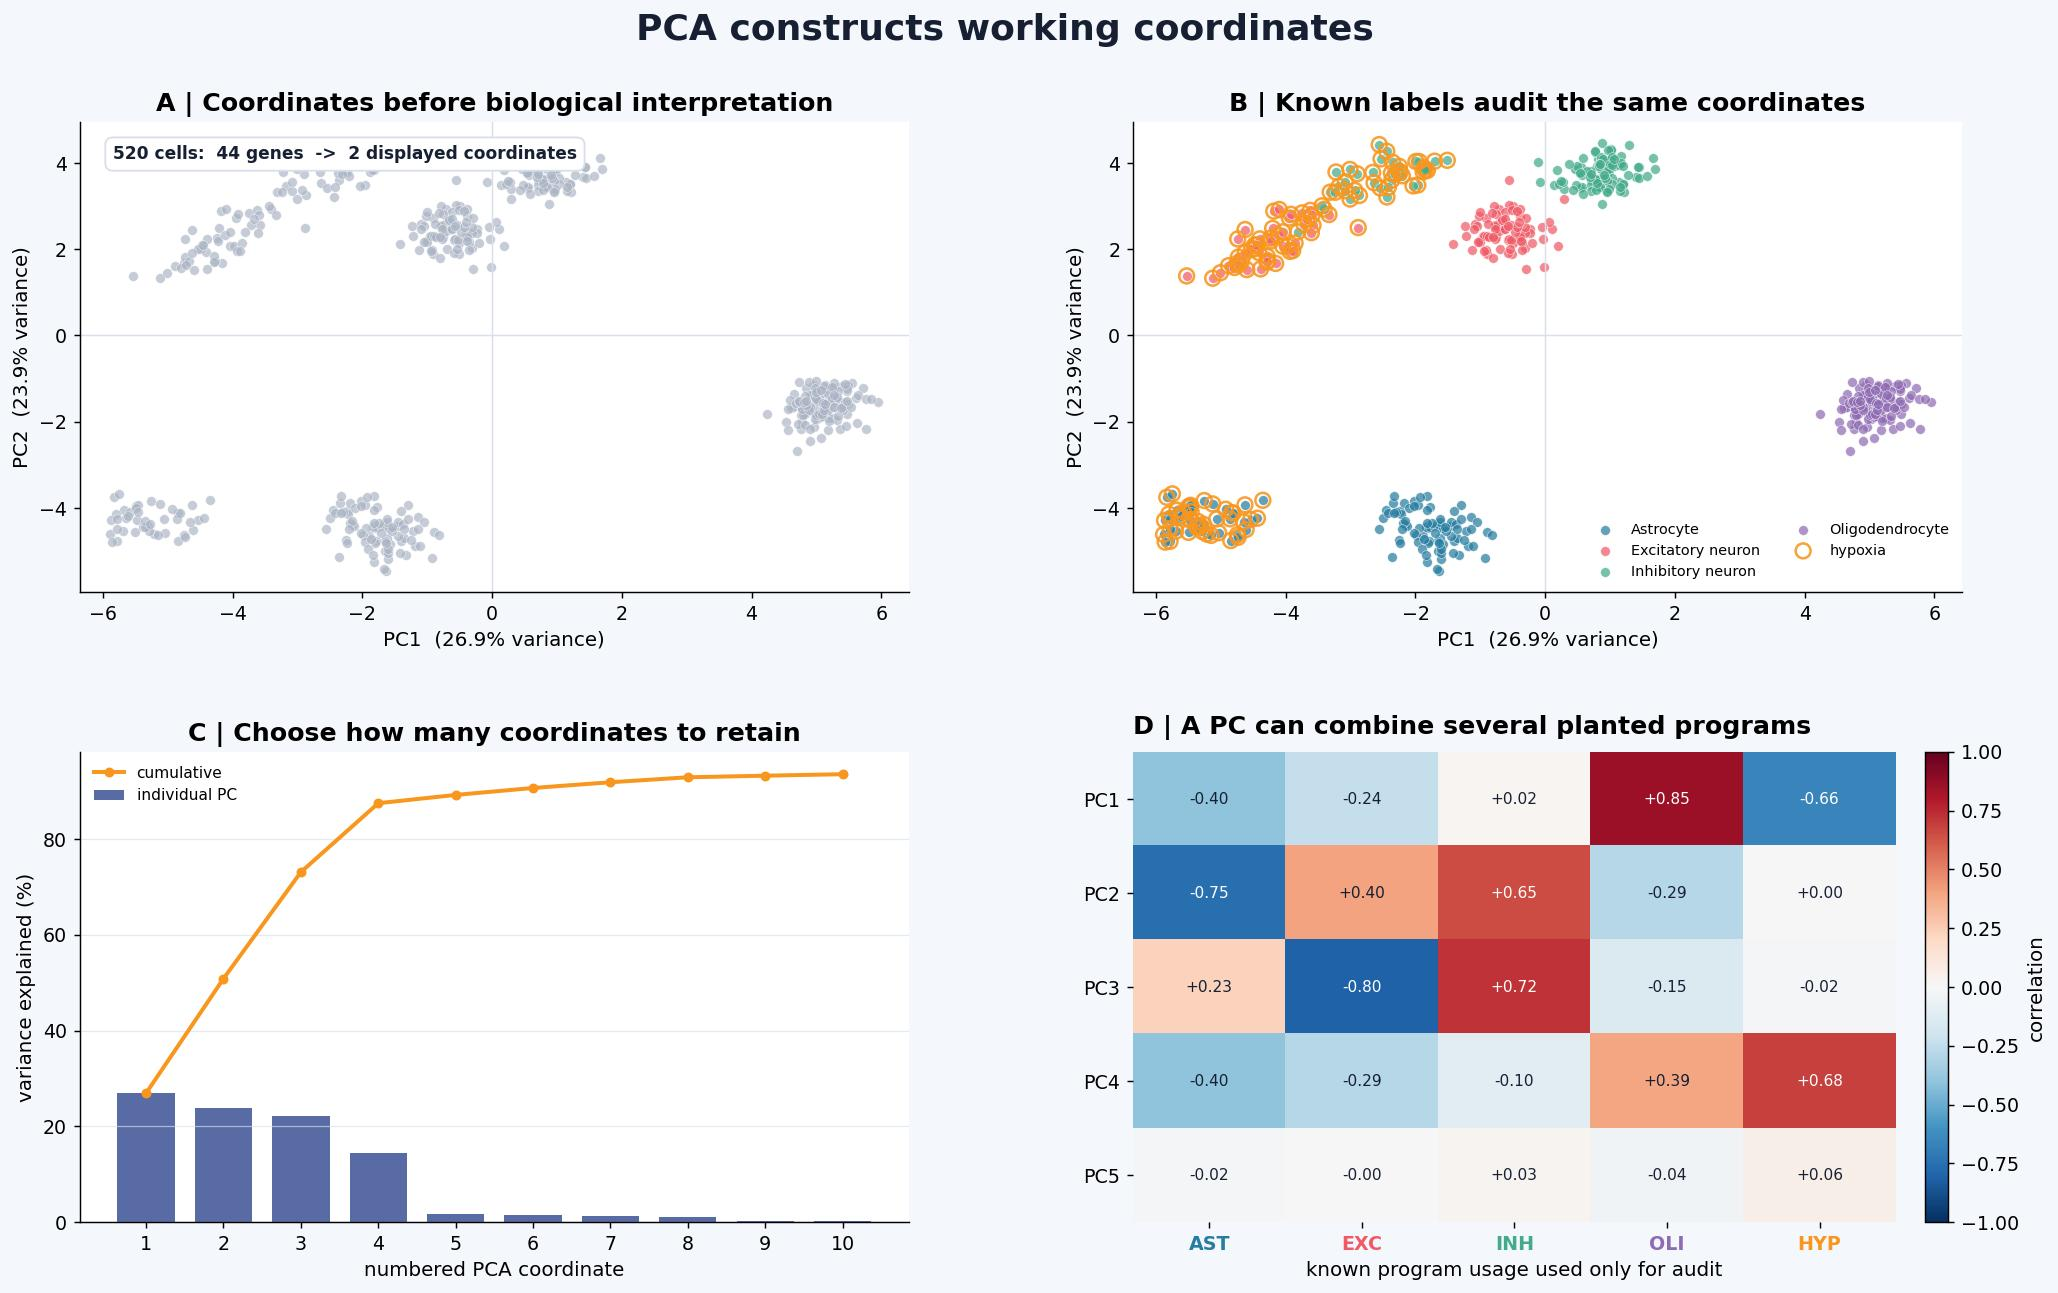

In [13]:
# PCA from first principles on the simulated single-cell matrix
def pca_fit(matrix, standardize=True):
    matrix = np.asarray(matrix, dtype=float)
    center = matrix.mean(axis=0)
    scale = matrix.std(axis=0, ddof=1) if standardize else np.ones(matrix.shape[1])
    scale[scale < 1e-12] = 1.0
    normalized = (matrix - center) / scale
    U, singular_values, components = np.linalg.svd(normalized, full_matrices=False)
    scores = U * singular_values
    explained_variance = singular_values ** 2 / (len(matrix) - 1)
    explained_ratio = explained_variance / explained_variance.sum()
    return {
        "center": center,
        "scale": scale,
        "scores": scores,
        "components": components,
        "singular_values": singular_values,
        "explained_ratio": explained_ratio,
    }

def pca_reconstruct(model, n_components):
    low_rank = (
        model["scores"][:, :n_components]
        @ model["components"][:n_components]
    )
    return low_rank * model["scale"] + model["center"]

pca_cells = pca_fit(X_log, standardize=True)
pc_scores = pca_cells["scores"]
pc_loadings = pca_cells["components"]
variance_ratio = pca_cells["explained_ratio"]

usage_pc_corr = np.corrcoef(pc_scores[:, :5].T, W_true.T)[:5, 5:]
shown_pcs = np.arange(1, 11)

fig = plt.figure(figsize=(16.0, 10.2), facecolor=BG)
gs = fig.add_gridspec(
    2, 2, left=0.055, right=0.96, bottom=0.07, top=0.90,
    hspace=0.34, wspace=0.27,
)
ax_coordinates = fig.add_subplot(gs[0, 0])
ax_audit = fig.add_subplot(gs[0, 1])
ax_scree = fig.add_subplot(gs[1, 0])
ax_corr = fig.add_subplot(gs[1, 1])

ax_coordinates.scatter(
    pc_scores[:, 0], pc_scores[:, 1],
    s=29, c="#AAB4C4", edgecolors="white",
    linewidths=0.32, alpha=0.68,
)
ax_coordinates.axhline(0, color=GRID, lw=0.8)
ax_coordinates.axvline(0, color=GRID, lw=0.8)
ax_coordinates.text(
    0.04, 0.95, f"{n_cells} cells:  {n_genes} genes  ->  2 displayed coordinates",
    transform=ax_coordinates.transAxes, ha="left", va="top",
    color=INK, fontsize=9.4, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec=GRID),
)
ax_coordinates.set(
    xlabel=f"PC1  ({variance_ratio[0]:.1%} variance)",
    ylabel=f"PC2  ({variance_ratio[1]:.1%} variance)",
    title="A | Coordinates before biological interpretation",
)

for k, (name, color) in enumerate(zip(CELL_TYPES, CELL_COLORS)):
    mask = cell_identity == k
    ax_audit.scatter(
        pc_scores[mask, 0], pc_scores[mask, 1], s=29, c=color,
        edgecolors="white", linewidths=0.34, alpha=0.72, label=name,
    )
ax_audit.scatter(
    pc_scores[active_cell, 0],
    pc_scores[active_cell, 1],
    s=68, facecolors="none", edgecolors=ACTIVITY_COLOR,
    linewidths=1.4, alpha=0.88, label="hypoxia",
)
ax_audit.axhline(0, color=GRID, lw=0.8)
ax_audit.axvline(0, color=GRID, lw=0.8)
ax_audit.set(
    xlabel=f"PC1  ({variance_ratio[0]:.1%} variance)",
    ylabel=f"PC2  ({variance_ratio[1]:.1%} variance)",
    title="B | Known labels audit the same coordinates",
)
ax_audit.legend(frameon=False, ncol=2, fontsize=8.0, loc="best")

x_limits = (
    min(pc_scores[:, 0]) - 0.04 * np.ptp(pc_scores[:, 0]),
    max(pc_scores[:, 0]) + 0.04 * np.ptp(pc_scores[:, 0]),
)
y_limits = (
    min(pc_scores[:, 1]) - 0.05 * np.ptp(pc_scores[:, 1]),
    max(pc_scores[:, 1]) + 0.05 * np.ptp(pc_scores[:, 1]),
)
for ax in (ax_coordinates, ax_audit):
    ax.set_xlim(*x_limits)
    ax.set_ylim(*y_limits)
    ax.spines[["top", "right"]].set_visible(False)

ax_scree.bar(
    shown_pcs, variance_ratio[:10] * 100,
    color="#586BA4", width=0.74, label="individual PC",
)
ax_scree.plot(
    shown_pcs, np.cumsum(variance_ratio[:10]) * 100,
    color=ACTIVITY_COLOR, marker="o", ms=4.5, lw=2.2,
    label="cumulative",
)
ax_scree.set(
    xlabel="numbered PCA coordinate",
    ylabel="variance explained (%)",
    title="C | Choose how many coordinates to retain",
    xticks=shown_pcs,
)
ax_scree.legend(frameon=False, fontsize=8.5)
ax_scree.spines[["top", "right"]].set_visible(False)
ax_scree.grid(axis="y", color=GRID, lw=0.7, alpha=0.65)

corr_image = ax_corr.imshow(
    usage_pc_corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto",
)
ax_corr.set_xticks(range(N_PROGRAMS), PROGRAM_SHORT)
ax_corr.set_yticks(range(5), [f"PC{k}" for k in range(1, 6)])
for row in range(5):
    for col in range(N_PROGRAMS):
        value = usage_pc_corr[row, col]
        ax_corr.text(
            col, row, f"{value:+.2f}", ha="center", va="center",
            fontsize=8.5, color="white" if abs(value) > 0.52 else INK,
        )
ax_corr.set_title("D | A PC can combine several planted programs", loc="left", pad=10)
ax_corr.set_xlabel("known program usage used only for audit")
for tick, color in zip(ax_corr.get_xticklabels(), PROGRAM_COLORS):
    tick.set_color(color)
    tick.set_fontweight("bold")
for spine in ax_corr.spines.values():
    spine.set_visible(False)
colorbar = fig.colorbar(corr_image, ax=ax_corr, fraction=0.045, pad=0.035)
colorbar.set_label("correlation")

fig.suptitle(
    "PCA constructs working coordinates",
    y=0.982, fontsize=20, fontweight="bold", color=INK,
)
plt.show()


The spirit we want to show within these biological application visualizations is that:

PCA, and other data processing within this notebook, do not automatically guarantee biological mechanism discovery. The more essential and direct value of PCA is that it's seeking for the linear projection with most information preserved(fig C). With just 4 PC coordinates, more than 80% information kept. 

#### Play around: the same real PBMC cells in PCA space

Your task is to calculate a 50-dimensional PCA representation from the prepared expression matrix. Use `run_pca(expression, n_components=50, random_state=7)`. It returns a cells-by-components array.

Only the TODO line is missing; all other code is ready. Once the figure appears, change `PC_X` / `PC_Y`. Some biological groups separate, but several remain mixed because PCA spends its axes on global variance rather than explicitly separating neighborhoods.

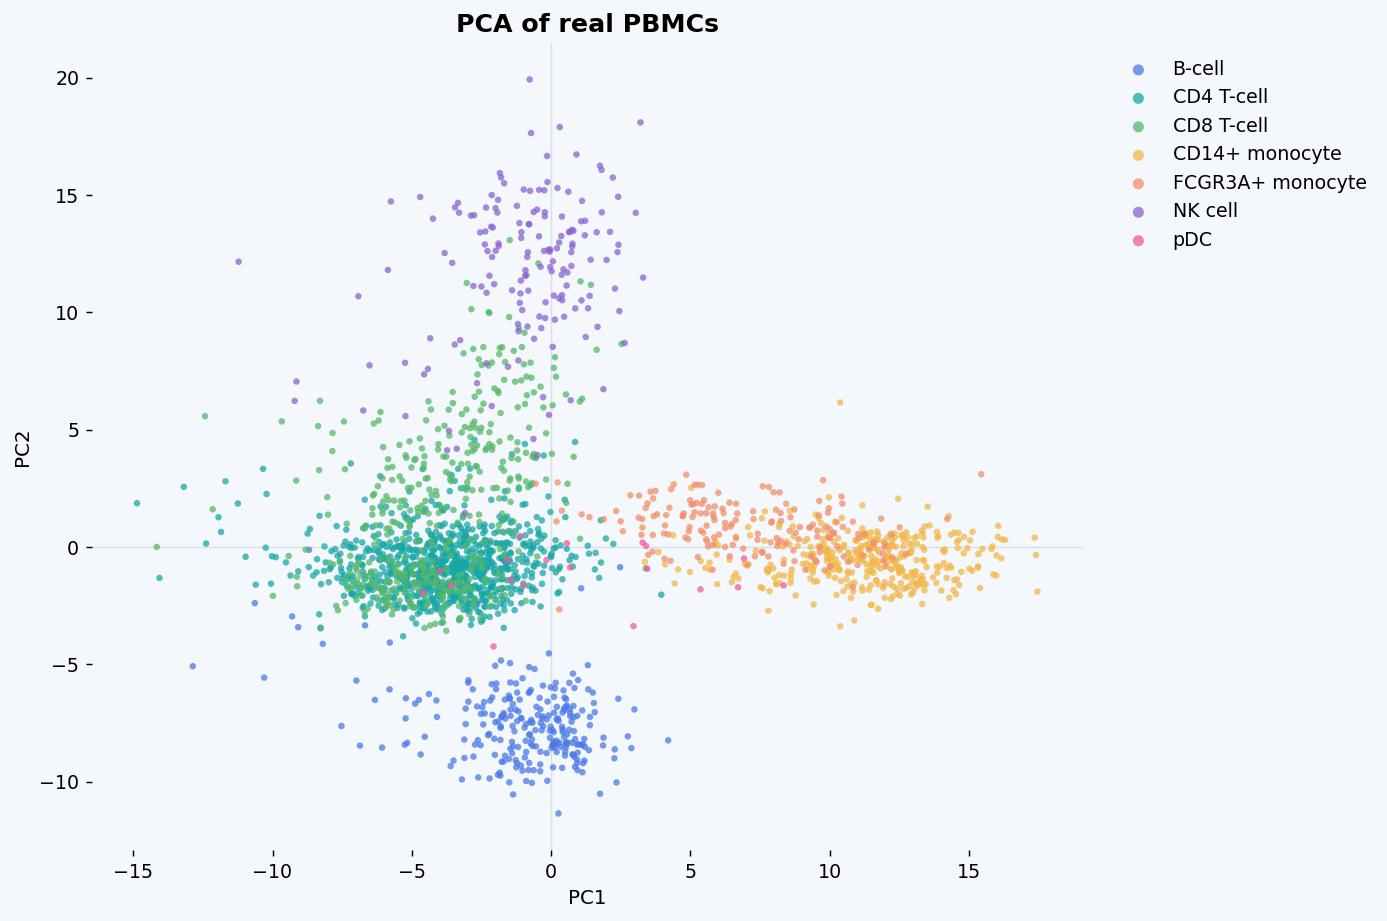

In [14]:
# Try (1, 2), (2, 3), or (1, 4), and optionally show only selected cell types
PC_X, PC_Y = 1, 2
POINT_SIZE = 13
ALPHA = 0.74
CELL_TYPES = None  # e.g. ["CD4 T-cell", "CD8 T-cell", "NK cell"]

if "pbmc_play" not in globals():
    from pathlib import Path
    import importlib, runpy, subprocess, sys
    try:
        import h5py
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "h5py"])
        h5py = importlib.import_module("h5py")
    tutorial_candidates = [Path.cwd(), Path.cwd() / "codes"]
    tutorial_dir = next(path for path in tutorial_candidates if (path / "pbmc_playground.py").exists())
    playground_api = runpy.run_path(str(tutorial_dir / "pbmc_playground.py"))
    load_pbmc3k = playground_api["load_pbmc3k"]
    run_pca = playground_api["run_pca"]
    run_tsne = playground_api["run_tsne"]
    cell_type_order = playground_api["CELL_TYPE_ORDER"]
    pbmc_palette = playground_api["PBMC_PALETTE"]
    pbmc_play = load_pbmc3k(tutorial_dir.parent / "data")

# TODO: implement task: create pca_coordinates with run_pca(...)

if PC_X < 1 or PC_Y < 1 or PC_X > pca_coordinates.shape[1] or PC_Y > pca_coordinates.shape[1]:
    raise ValueError("PC_X and PC_Y must be between 1 and 50")

labels = np.asarray(pbmc_play["cell_type"])
selected_types = cell_type_order if CELL_TYPES is None else CELL_TYPES

fig, ax = plt.subplots(figsize=(10.8, 7.2), facecolor="#F4F7FB")
ax.set_facecolor("#F4F7FB")
for cell_type in selected_types:
    mask = labels == cell_type
    ax.scatter(
        pca_coordinates[mask, PC_X - 1], pca_coordinates[mask, PC_Y - 1],
        s=POINT_SIZE, alpha=ALPHA, color=pbmc_palette[cell_type],
        edgecolors="none", label=cell_type,
    )

ax.set(
    title="PCA of real PBMCs",
    xlabel=f"PC{PC_X}", ylabel=f"PC{PC_Y}",
)
ax.axhline(0, color="#D8E0EB", lw=0.8, zorder=0)
ax.axvline(0, color="#D8E0EB", lw=0.8, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.7)
plt.tight_layout()
plt.show()


### 3.2 Non-Negative Matrix Factorization

#### One cell is an additive mixture of gene programs

A **gene program** $\mathbf{w}_k\geq 0$ is a reusable expression pattern across genes. Its **activity** $h_k\geq 0$ tells us how much that program contributes to this particular cell. NMF explains the observed vector by adding the active programs:

$$
\mathbf{x}\approx \sum_{k=1}^{K}h_k\mathbf{w}_k.
$$

Because every contribution is nonnegative, the colored pieces below stack—one program never has to cancel another.

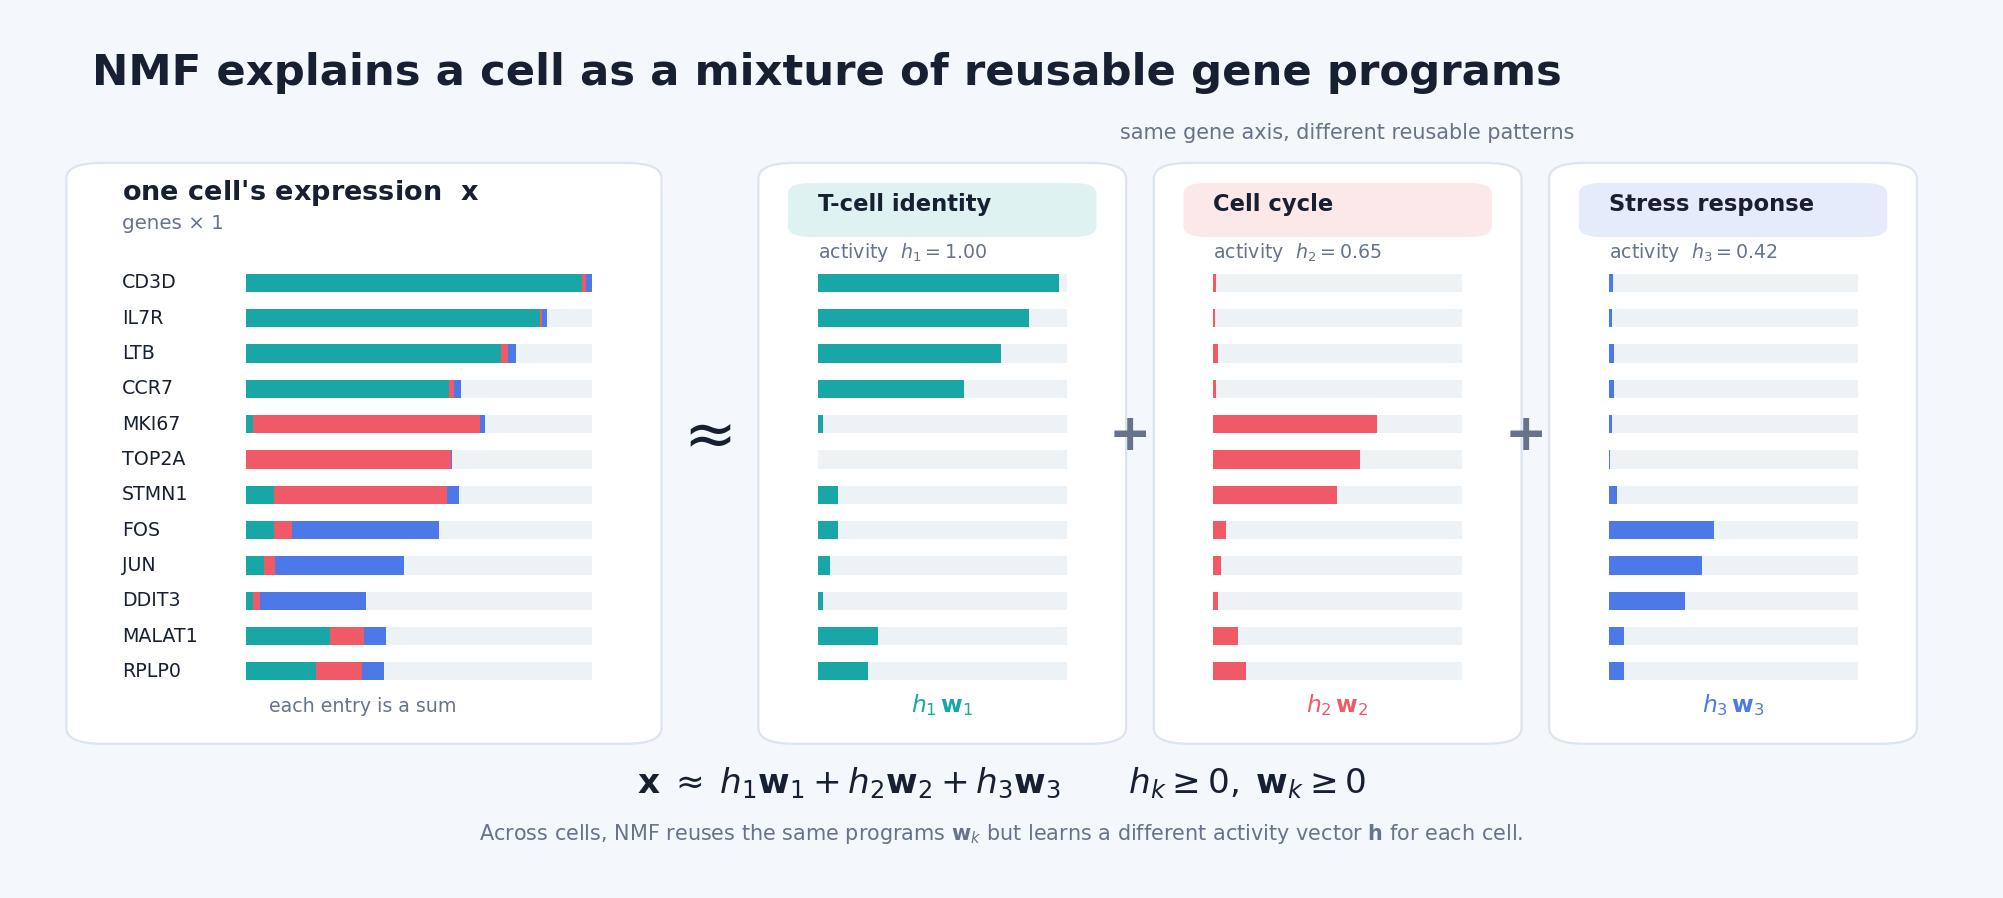

In [15]:
# NMF intuition: one expression vector as an additive mixture of gene programs
from pathlib import Path
import runpy

nmf_figure_candidates = [
    Path("nmf-vector-programs.py"),
    Path("codes/nmf-vector-programs.py"),
]
nmf_figure_path = next((path for path in nmf_figure_candidates if path.exists()), None)
if nmf_figure_path is None:
    raise FileNotFoundError("Could not locate nmf-vector-programs.py")

_ = runpy.run_path(str(nmf_figure_path))


#### Matrix view and optimization

$$
X\approx WH,
\qquad
X\in\mathbb{R}_{+}^{n\times p},\;
W\in\mathbb{R}_{+}^{n\times k},\;
H\in\mathbb{R}_{+}^{k\times p}.
$$

NMF searches for nonnegative factors that reconstruct the data:

$$
\min_{W,H\geq 0}\;\mathcal{L}(W,H)
=\frac{1}{2}\lVert X-WH\rVert_F^2.
$$

The gradients are

$$
\nabla_W\mathcal{L}=(WH-X)H^\top,
\qquad
\nabla_H\mathcal{L}=W^\top(WH-X).
$$

A simple projected-gradient update is

$$
W\leftarrow\left[W-\eta_W\nabla_W\mathcal{L}\right]_+,
\qquad
H\leftarrow\left[H-\eta_H\nabla_H\mathcal{L}\right]_+,
$$

where $[A]_+=\max(A,0)$ keeps every entry nonnegative.


#### Application: nonnegative spatial factorization

Spatial NMF adds each observation's **spatial coordinates** as an extra input, allowing the learned factors to depend on where the observation lies in the tissue.

<div style="text-align: center;">
  <img src="../data/spatio_NMF.png" alt="Spatial factors and spatially variable genes identified by nonnegative spatial factorization" style="width: 92%; max-width: 1100px;">
</div>

*Reference: F. William Townes and Barbara E. Engelhardt, [“Nonnegative spatial factorization applied to spatial genomics”](https://doi.org/10.1038/s41592-022-01687-w), Nature Methods 20, 229–238 (2023).*


## Computing environment

| Package | Version |
|---|---:|
| Python | 3.11.x |
| JupyterLab | 4.x |
| IPython | 8.x |
| NumPy | 2.x |
| SciPy | 1.13.x |
| Matplotlib | 3.9.x |
| scikit-learn | 1.5.x |
| h5py | 3.11.x |

**Author**: Xinyu Wang

**Affiliation:** Westlake University

July 2026